# Phase 2 Gradient Dynamics 분석 노트북: HiP-AD vs VAD

이 노트북은 Phase 2에서 생성된 두 실험 결과를 **처음 보는 사람도 따라올 수 있도록** 설명하고 시각화합니다.

비교 대상은 다음 두 결과입니다.

- **HiP-AD:** `gradient_analysis_results/hipad_layer`
- **VAD:** `gradient_analysis_results/vad_bev_shared`

핵심 질문은 네 가지입니다.

1. HiP-AD와 VAD에서 multi-task gradient conflict가 실제로 강하게 나타나는가?
2. conflict가 있다면 어느 task pair와 어느 layer에서 생기는가?
3. 1-step probe에서 각 task의 gradient step은 자기 task와 다른 task loss에 어떤 영향을 주는가?
4. 최종적으로 algorithm design 관점에서 direction surgery가 중요한가, 아니면 magnitude rescaling / scheduling이 더 중요한가?

이 노트북의 결론은 단순히 “HiP-AD 요약, VAD 요약”이 아닙니다. 각 모델을 따로 뜯어보고, 마지막에 두 모델을 비교합니다.

## 0. 처음 보는 사람을 위한 개념 정리

이 분석은 multi-task learning에서 task 간 gradient가 어떻게 상호작용하는지 보는 실험입니다. 여기서 task는 `det`, `map`, `motion`, `plan` 네 가지입니다.

### Gradient cosine

두 task의 gradient 방향이 비슷한지 보려면 cosine similarity를 봅니다.

- cosine > 0: 두 task가 비슷한 방향으로 parameter를 바꾸고 싶어 함
- cosine < 0: 한 task가 좋아지는 방향이 다른 task에는 나쁠 수 있음
- cosine ≈ 0: 거의 직교하거나 signal이 약함

### Conflict ratio

각 batch마다 cosine을 계산한 뒤, 음수인 batch 비율을 `conflict_ratio`라고 둡니다.

- 0.5면 batch 절반에서 conflict 방향
- 0.7이면 상당히 자주 conflict 방향
- 하지만 conflict ratio만 보면 안 됩니다. mean cosine이 -0.001처럼 거의 0이면, 부호는 자주 음수여도 효과 크기는 작을 수 있습니다.

### Null-baseline pass rate

관측된 cosine이 noise와 구분되는지 확인하기 위한 검정입니다.

- `sign_flip`: 평균 cosine이 0과 다른지 보는 성격이 강함
- `batch_permutation`: batch 구조를 섞었을 때도 같은 신호가 남는지 보는 더 보수적인 기준

Phase 1에서는 pass rate 30%를 direction-conflict signal의 중요한 기준으로 사용했습니다.

### 1-step probe

Source task의 gradient 방향으로 parameter를 아주 조금 움직인 뒤, target task loss가 어떻게 변하는지 봅니다.

- `delta < 0`: target loss 감소, helpful
- `delta > 0`: target loss 증가, harmful
- `source == target`: 자기 task 방향으로 자기 loss가 줄어야 정상
- `source != target`: cross-task transfer 또는 interference를 보는 부분

여기서 중요한 점은 helpful ratio가 0.55처럼 0.5보다 조금 높아도, mean delta가 거의 0이면 강한 효과라고 말하기 어렵다는 점입니다.

> **Note (2026-05-12):** This notebook has been refactored around plan-centric directed transfer (Parts F–K). The original Part A–E analyses are now in the Appendix.


## 1. 데이터 로딩

아래 코드는 원본 실험을 다시 돌리지 않습니다. 이미 생성된 CSV 산출물을 읽어서 표와 그림을 만듭니다.

사용하는 주요 산출물은 다음입니다.

- `layer_conflict/conflict_*_summary.csv`: layer별 task-pair gradient conflict
- `conflict/conflict_*_summary.csv`: 기본 shared group 기준 conflict
- `null_baseline/null_baseline.csv`: permutation/sign-flip null 검정
- `distribution/distribution_report.csv`: cosine 분포 형태
- `layer_correlation/layer_correlation_table.csv`: cosine과 1-step loss 변화의 상관
- `probe/probe_per_batch.csv`: 1-step probe의 source-target별 delta

In [13]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore')

REPO_ROOT = Path('/home/yongjae/e2e/HiP-AD')
RESULTS_ROOT = REPO_ROOT / 'gradient_analysis_results'

RUNS = {
    'HiP-AD': RESULTS_ROOT / 'hipad_layer',
    'VAD': RESULTS_ROOT / 'vad_bev_shared',
}

TASKS = ['det', 'map', 'motion', 'plan']
TASK_PAIRS = [('det', 'map'), ('det', 'motion'), ('det', 'plan'), ('map', 'motion'), ('map', 'plan'), ('motion', 'plan')]
TASK_PAIR_LABELS = [f'{a}-{b}' for a, b in TASK_PAIRS]

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

def checkpoint_sort_key(tag: str):
    digits = ''.join(ch for ch in tag if ch.isdigit())
    return int(digits) if digits else 0

def checkpoint_dirs(run_root: Path):
    dirs = [p for p in run_root.glob('ckpt_*') if p.is_dir()]
    return sorted(dirs, key=lambda p: checkpoint_sort_key(p.name.replace('ckpt_', '')))

def checkpoint_tag(path: Path):
    return path.name.replace('ckpt_', '')

def add_model_and_checkpoint(df: pd.DataFrame, model: str, ckpt_dir: Path):
    df = df.copy()
    df['model'] = model
    df['checkpoint'] = checkpoint_tag(ckpt_dir)
    df['checkpoint_order'] = checkpoint_sort_key(df['checkpoint'].iloc[0])
    return df

def load_conflict(subdir='layer_conflict'):
    frames = []
    for model, root in RUNS.items():
        for ckpt in checkpoint_dirs(root):
            folder = ckpt / subdir
            if not folder.exists():
                continue
            for csv_path in sorted(folder.glob('conflict_*_summary.csv')):
                df = pd.read_csv(csv_path)
                frames.append(add_model_and_checkpoint(df, model, ckpt))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def load_null_baseline():
    frames = []
    for model, root in RUNS.items():
        for ckpt in checkpoint_dirs(root):
            csv_path = ckpt / 'null_baseline' / 'null_baseline.csv'
            if csv_path.exists():
                frames.append(add_model_and_checkpoint(pd.read_csv(csv_path), model, ckpt))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def load_distribution():
    frames = []
    for model, root in RUNS.items():
        for ckpt in checkpoint_dirs(root):
            csv_path = ckpt / 'distribution' / 'distribution_report.csv'
            if csv_path.exists():
                frames.append(add_model_and_checkpoint(pd.read_csv(csv_path), model, ckpt))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def load_layer_correlation():
    frames = []
    for model, root in RUNS.items():
        for ckpt in checkpoint_dirs(root):
            csv_path = ckpt / 'layer_correlation' / 'layer_correlation_table.csv'
            if csv_path.exists():
                frames.append(add_model_and_checkpoint(pd.read_csv(csv_path), model, ckpt))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def load_probe():
    frames = []
    for model, root in RUNS.items():
        for ckpt in checkpoint_dirs(root):
            csv_path = ckpt / 'probe' / 'probe_per_batch.csv'
            if csv_path.exists():
                frames.append(add_model_and_checkpoint(pd.read_csv(csv_path), model, ckpt))
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def real_rows(df):
    if 'is_pseudo_shared_group' not in df.columns:
        return df.copy()
    return df[~df['is_pseudo_shared_group'].fillna(False)].copy()

layer_conflict = load_conflict('layer_conflict')
base_conflict = load_conflict('conflict')
null_baseline = load_null_baseline()
distribution = load_distribution()
correlation = load_layer_correlation()
probe = load_probe()
real_layer_conflict = real_rows(layer_conflict)
real_base_conflict = real_rows(base_conflict)

print('Loaded rows')
print('layer_conflict:', len(layer_conflict))
print('base_conflict:', len(base_conflict))
print('null_baseline:', len(null_baseline))
print('distribution:', len(distribution))
print('correlation:', len(correlation))
print('probe:', len(probe))

from tools.gradient_analysis.plan_centric import (
    ensure_columns,
    bootstrap_ci,
    practical_threshold,
    standardize_probe_df,
    get_probe_base,
)

probe = standardize_probe_df(probe)
base = get_probe_base(probe, variant='normalized', steps=1)
print('base rows:', len(base))


Loaded rows
layer_conflict: 480
base_conflict: 312
null_baseline: 624
distribution: 312
correlation: 1920
probe: 256000


# Part F. Plan-centric directed transfer

Question: 각 task의 1-step update가 planning loss를 줄이는가?
Source: `det`, `map`, `motion`, `plan`. Target: `plan`.


In [ ]:
from pathlib import Path
from tools.gradient_analysis.plan_centric import (
    build_plan_transfer_summary, top_beneficial, top_harmful,
)
OUT_DIR = Path('gradient_analysis_results/plan_centric')
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / 'figures/F').mkdir(parents=True, exist_ok=True)
plan_transfer = build_plan_transfer_summary(base)
plan_transfer.to_csv(OUT_DIR / 'plan_transfer_summary.csv', index=False)
display(plan_transfer.head())


In [ ]:
import matplotlib.pyplot as plt
SRC_ORDER = ['det', 'map', 'motion', 'plan']
for (model, ckpt), sub in plan_transfer.groupby(['model', 'checkpoint']):
    for metric in ['mean_gain', 'practical_helpful_rate']:
        pivot = sub.pivot_table(index='layer', columns='source_task', values=metric).reindex(columns=SRC_ORDER)
        fig, ax = plt.subplots(figsize=(6, max(3, 0.3 * len(pivot))))
        cmap = 'RdBu_r' if metric == 'mean_gain' else 'viridis'
        im = ax.imshow(pivot.values, aspect='auto', cmap=cmap)
        ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index, fontsize=8)
        ax.set_title(f'{model} {ckpt}: target=plan, {metric}')
        fig.colorbar(im, ax=ax)
        fig.tight_layout()
        fig.savefig(OUT_DIR / f'figures/F/{model}_{ckpt}_{metric}.png', dpi=120)
        plt.show()


In [ ]:
top_ben = top_beneficial(plan_transfer, k=10, by='mean_gain')
top_ben.to_csv(OUT_DIR / 'plan_transfer_top_beneficial.csv', index=False)
display(top_ben)
top_harm = top_harmful(plan_transfer, k=10, by='mean_gain')
top_harm.to_csv(OUT_DIR / 'plan_transfer_top_harmful.csv', index=False)
display(top_harm)


# Part G. Directed asymmetry around planning

`A → plan` vs `plan → A`, A ∈ {det, map, motion}.


In [ ]:
from tools.gradient_analysis.plan_centric import build_asymmetry_summary
(OUT_DIR / 'figures/G').mkdir(parents=True, exist_ok=True)
asym = build_asymmetry_summary(base)
asym.to_csv(OUT_DIR / 'plan_asymmetry_summary.csv', index=False)
asym[['model','checkpoint','layer','aux_task','asymmetry','plan_transfer_ratio']].to_csv(
    OUT_DIR / 'plan_transfer_ratio_summary.csv', index=False)
display(asym.head())


In [ ]:
AUX_ORDER = ['det', 'map', 'motion']
for (model, ckpt), sub in asym.groupby(['model', 'checkpoint']):
    for metric in ['asymmetry', 'plan_transfer_ratio']:
        pivot = sub.pivot_table(index='layer', columns='aux_task', values=metric).reindex(columns=AUX_ORDER)
        fig, ax = plt.subplots(figsize=(5, max(3, 0.3 * len(pivot))))
        im = ax.imshow(pivot.values, aspect='auto', cmap='RdBu_r')
        ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index, fontsize=8)
        ax.set_title(f'{model} {ckpt}: {metric}')
        fig.colorbar(im, ax=ax); fig.tight_layout()
        fig.savefig(OUT_DIR / f'figures/G/{model}_{ckpt}_{metric}.png', dpi=120)
        plt.show()


In [ ]:
for model, sub in asym.groupby('model'):
    for metric in ['asymmetry', 'plan_transfer_ratio']:
        fig, ax = plt.subplots(figsize=(7, 4))
        for aux, sub2 in sub.groupby('aux_task'):
            agg = sub2.groupby('checkpoint_order')[metric].mean()
            ax.plot(agg.index, agg.values, marker='o', label=aux)
        ax.axhline(0, color='gray', lw=0.5)
        ax.set_xlabel('checkpoint_order'); ax.set_ylabel(metric)
        ax.set_title(f'{model}: {metric} trend')
        ax.legend(); fig.tight_layout()
        fig.savefig(OUT_DIR / f'figures/G/{model}_{metric}_trend.png', dpi=120)
        plt.show()


In [ ]:
display(asym[['model','checkpoint','layer','aux_task','interpretation']].head(20))


# Part H. Effect-size-aware 1-step probe

Helpful ratio alone overweights noisy near-zero deltas. Effect size = mean_gain / std_delta.


In [ ]:
from tools.gradient_analysis.plan_centric import build_effect_size_summary
(OUT_DIR / 'figures/H').mkdir(parents=True, exist_ok=True)
effect = build_effect_size_summary(base, target='plan')
effect.to_csv(OUT_DIR / 'effect_size_probe_summary.csv', index=False)
effect[['model','checkpoint','layer','source_task','helpful_rate','mean_gain','effect_size']].to_csv(
    OUT_DIR / 'helpful_vs_effect_size.csv', index=False)
display(effect.head())


In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = {'det':'C0','map':'C1','motion':'C2','plan':'C3'}
markers = {'HiP-AD':'o','VAD':'s'}
for (model, src), sub in effect.groupby(['model','source_task']):
    ax.scatter(sub['helpful_rate'], sub['mean_gain'],
               c=colors.get(src,'gray'), marker=markers.get(model,'x'),
               alpha=0.6, label=f'{model}/{src}')
top = effect.reindex(effect['mean_gain'].abs().sort_values(ascending=False).index).head(15)
for _, r in top.iterrows():
    ax.annotate(f"{r['layer']}/{r['source_task'][:3]}", (r['helpful_rate'], r['mean_gain']),
                fontsize=7, alpha=0.7)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0.5, color='gray', lw=0.5)
ax.set_xlabel('helpful_rate'); ax.set_ylabel('mean_gain (plan)')
ax.set_title('helpful_rate vs mean_gain (target=plan)')
ax.legend(fontsize=7, ncol=2); fig.tight_layout()
fig.savefig(OUT_DIR / 'figures/H/helpful_vs_gain_scatter.png', dpi=120)
plt.show()


In [ ]:
import numpy as np
for model, sub in effect.groupby('model'):
    fig, ax = plt.subplots(figsize=(8, 4))
    pos = 0; xticks = []; xlabels = []
    for src, sub2 in sub.groupby('source_task'):
        top = sub2.reindex(sub2['mean_gain'].abs().sort_values(ascending=False).index).head(5)
        for _, r in top.iterrows():
            ax.errorbar(pos, r['mean_gain'],
                        yerr=[[r['mean_gain']-r['ci_lo_gain']],[r['ci_hi_gain']-r['mean_gain']]],
                        fmt='o', color=colors.get(src,'gray'))
            xticks.append(pos); xlabels.append(f"{src[:3]}/{r['layer'][:10]}"); pos += 1
        pos += 1
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xticks(xticks); ax.set_xticklabels(xlabels, rotation=60, ha='right', fontsize=7)
    ax.set_ylabel('mean_gain ± 95% CI'); ax.set_title(f'{model}: top influential layers')
    fig.tight_layout(); fig.savefig(OUT_DIR / f'figures/H/{model}_top_layers_ci.png', dpi=120)
    plt.show()


In [ ]:
flag_cols = ['flag_high_helpful_low_gain','flag_positive_but_insig',
             'flag_high_practical_helpful','flag_high_large_harm']
for fc in flag_cols:
    flagged = effect[effect[fc]]
    print(f'{fc}: {len(flagged)} rows')
    if not flagged.empty:
        display(flagged[['model','checkpoint','layer','source_task','mean_gain','helpful_rate']].head(10))


# Part I. First-order prediction vs actual 1-step effect

Checks whether actual ΔL matches the linear prediction `-step_size · <g_src, g_tgt>`.


In [ ]:
from tools.gradient_analysis.plan_centric import (
    detect_first_order_columns, build_first_order_residual_summary,
)
(OUT_DIR / 'figures/I').mkdir(parents=True, exist_ok=True)
fo_cols = detect_first_order_columns(probe)
if fo_cols is None:
    print('SKIPPED. Required columns for first-order analysis:')
    print('- source_task\n- target_task\n- model\n- checkpoint\n- layer\n- delta')
    print('- grad_dot (or equivalent)\n- step_size / lr / probe_lr')
    first_order = None
else:
    first_order = build_first_order_residual_summary(base, fo_cols)
    first_order.to_csv(OUT_DIR / 'first_order_vs_actual_summary.csv', index=False)
    first_order[first_order['target_task']=='plan'].to_csv(
        OUT_DIR / 'first_order_residual_by_layer.csv', index=False)
    display(first_order.head())


In [ ]:
import numpy as np
if first_order is not None:
    df_full = base.copy()
    df_full['pred_delta'] = -df_full[fo_cols['step_size']] * df_full[fo_cols['grad_dot']]
    df_full['residual'] = df_full['delta'] - df_full['pred_delta']
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(df_full['pred_delta'], df_full['delta'], alpha=0.4, s=8)
    lim = max(abs(df_full['pred_delta'].min()), abs(df_full['delta'].max()))
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=0.5)
    ax.set_xlabel('predicted -lr·<g_s,g_t>'); ax.set_ylabel('actual ΔL')
    ax.set_title('Actual vs first-order prediction')
    fig.tight_layout(); fig.savefig(OUT_DIR / 'figures/I/actual_vs_pred.png', dpi=120)
    plt.show()
    plan_res = first_order[first_order['target_task'] == 'plan']
    for (model, ckpt), sub in plan_res.groupby(['model', 'checkpoint']):
        pivot = sub.pivot_table(index='layer', columns='source_task', values='mean_residual').reindex(columns=['det','map','motion','plan'])
        fig, ax = plt.subplots(figsize=(5, max(3, 0.3*len(pivot))))
        im = ax.imshow(pivot.values, aspect='auto', cmap='RdBu_r')
        ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index, fontsize=8)
        ax.set_title(f'{model} {ckpt}: residual (plan target)')
        fig.colorbar(im, ax=ax); fig.tight_layout()
        fig.savefig(OUT_DIR / f'figures/I/{model}_{ckpt}_residual_plan.png', dpi=120)
        plt.show()
    for model, sub in df_full.groupby('model'):
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.hist(sub['residual'], bins=60)
        ax.set_title(f'{model}: residual distribution'); ax.set_xlabel('actual - predicted')
        fig.tight_layout(); fig.savefig(OUT_DIR / f'figures/I/{model}_residual_hist.png', dpi=120)
        plt.show()


# Part J. Planning sensitivity and query reachability

Loads `query_sensitivity.csv` if produced by the runner. Missing file → template + SKIP.


In [ ]:
import os
from tools.gradient_analysis.plan_centric import (
    load_or_template_query_sensitivity, build_query_sensitivity_summary,
)
(OUT_DIR / 'figures/J').mkdir(parents=True, exist_ok=True)
QUERY_SENSITIVITY_PATH = Path(os.environ.get(
    'QUERY_SENSITIVITY_PATH', OUT_DIR / 'query_sensitivity.csv'))
qs_df, status = load_or_template_query_sensitivity(QUERY_SENSITIVITY_PATH)
if status == 'template':
    print(f'SKIPPED. Template written to {QUERY_SENSITIVITY_PATH}.')
    print('Populate via tools/gradient_analysis/query_sensitivity.run_query_sensitivity')
    qs_summary = None
else:
    qs_summary = build_query_sensitivity_summary(qs_df)
    qs_summary.to_csv(OUT_DIR / 'query_sensitivity_summary.csv', index=False)
    display(qs_summary.head())


In [ ]:
if qs_summary is not None and not qs_summary.empty:
    TASK_ORDER = ['det','map','motion','plan']
    for (model, ckpt), sub in qs_summary.groupby(['model','checkpoint']):
        agg = sub.groupby('task_query_type')['mean_sensitivity'].mean().reindex(TASK_ORDER)
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.bar(agg.index, agg.values)
        ax.set_title(f'{model} {ckpt}: mean planning sensitivity by query task')
        fig.tight_layout(); fig.savefig(OUT_DIR / f'figures/J/{model}_{ckpt}_sens_bar.png', dpi=120)
        plt.show()
        pivot = sub.pivot_table(index='layer', columns='task_query_type',
                                values='mean_sensitivity').reindex(columns=TASK_ORDER)
        if not pivot.empty:
            fig, ax = plt.subplots(figsize=(5, max(3, 0.3 * len(pivot))))
            im = ax.imshow(pivot.values, aspect='auto', cmap='viridis')
            ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
            ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index, fontsize=8)
            ax.set_title(f'{model} {ckpt}: layer × task_query_type sensitivity')
            fig.colorbar(im, ax=ax); fig.tight_layout()
            fig.savefig(OUT_DIR / f'figures/J/{model}_{ckpt}_sens_heatmap.png', dpi=120)
            plt.show()
    for model, sub in qs_summary.groupby('model'):
        fig, ax = plt.subplots(figsize=(6, 3))
        for tq, sub2 in sub.groupby('task_query_type'):
            agg = sub2.groupby('checkpoint_order')['mean_sensitivity'].mean()
            ax.plot(agg.index, agg.values, marker='o', label=tq)
        ax.set_xlabel('checkpoint_order'); ax.set_ylabel('mean_sensitivity')
        ax.set_title(f'{model}: planning sensitivity over training')
        ax.legend(); fig.tight_layout()
        fig.savefig(OUT_DIR / f'figures/J/{model}_sens_trend.png', dpi=120)
        plt.show()


# Part K. Task loss weight elasticity

Loads `task_weight_elasticity_runs.csv`. Missing file → template + SKIP.


In [ ]:
import os
from tools.gradient_analysis.plan_centric import (
    load_or_template_elasticity, build_elasticity_summary,
    planning_safe_weight_range,
)
(OUT_DIR / 'figures/K').mkdir(parents=True, exist_ok=True)
ELASTICITY_LOG_PATH = Path(os.environ.get(
    'ELASTICITY_LOG_PATH', OUT_DIR / 'task_weight_elasticity_runs.csv'))
el_df, status = load_or_template_elasticity(ELASTICITY_LOG_PATH)
if status == 'template':
    print(f'SKIPPED. Template written to {ELASTICITY_LOG_PATH}.')
    elasticity = None
else:
    elasticity = build_elasticity_summary(el_df)
    elasticity.to_csv(OUT_DIR / 'task_weight_elasticity_summary.csv', index=False)
    safe = planning_safe_weight_range(elasticity, tol=0.01)
    safe.to_csv(OUT_DIR / 'planning_safe_weight_range.csv', index=False)
    display(elasticity.head())


# Appendix. Diagnostic background

Below are the original Part A–E analyses (global conflict, null baseline, distribution, affinity, heavy-tail, self-violation). They are preserved verbatim for traceability but the main story now lives in Parts F–K above. Read these only when you need to verify background claims.


In [ ]:
if elasticity is not None and not elasticity.empty:
    for swept, sub in elasticity.groupby('swept_task'):
        fig, axes = plt.subplots(1, 2, figsize=(10, 3))
        for model, sub2 in sub.groupby('model'):
            sub2 = sub2.sort_values('log_lambda')
            axes[0].plot(sub2['log_lambda'], sub2['task_metric'], 'o-', label=model)
            axes[1].plot(sub2['log_lambda'], sub2['plan_metric'], 'o-', label=model)
        axes[0].set_title(f'lambda_{swept} vs task_metric'); axes[0].legend()
        axes[1].set_title(f'lambda_{swept} vs plan_metric'); axes[1].legend()
        axes[0].set_xlabel('log(lambda)'); axes[1].set_xlabel('log(lambda)')
        fig.tight_layout(); fig.savefig(OUT_DIR / f'figures/K/{swept}_lambda_curves.png', dpi=120)
        plt.show()
    fig, ax = plt.subplots(figsize=(6, 4))
    for (swept, model), sub in elasticity.groupby(['swept_task','model']):
        ax.scatter(sub['relative_task_metric'], sub['relative_plan_metric'],
                   label=f'{model}/{swept}', s=30)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlabel('relative task gain (+ better)')
    ax.set_ylabel('relative plan degradation (+ worse for plan_l2)')
    ax.set_title('Pareto: task gain vs plan degradation')
    ax.legend(fontsize=7); fig.tight_layout()
    fig.savefig(OUT_DIR / 'figures/K/pareto.png', dpi=120); plt.show()
    display(safe[safe['planning_safe']])


In [14]:
def conflict_summary(df=real_layer_conflict):
    return (
        df.groupby(['model', 'checkpoint', 'checkpoint_order'])
        .agg(
            cells=('conflict_ratio', 'size'),
            mean_conflict=('conflict_ratio', 'mean'),
            median_conflict=('conflict_ratio', 'median'),
            p90_conflict=('conflict_ratio', lambda s: s.quantile(0.90)),
            high_ge_050=('conflict_ratio', lambda s: (s >= 0.50).mean()),
            mean_cos=('mean_cos', 'mean'),
            mean_abs_cos=('mean_cos', lambda s: s.abs().mean()),
        )
        .reset_index()
        .sort_values(['model', 'checkpoint_order'])
    )

def null_summary():
    return (
        null_baseline.groupby(['model', 'checkpoint', 'checkpoint_order'])['passes_noise_threshold']
        .mean()
        .reset_index(name='pass_rate')
        .sort_values(['model', 'checkpoint_order'])
    )

def probe_norm_tables():
    norm = probe[(probe['steps'] == 1) & (probe['variant'] == 'normalized')]
    # grad_norm is repeated once per target task, so de-duplicate first.
    base = norm[['model', 'checkpoint', 'checkpoint_order', 'batch_idx', 'layer', 'source_task', 'grad_norm']].drop_duplicates()
    by_task = (
        base.groupby(['model', 'checkpoint', 'checkpoint_order', 'source_task'])['grad_norm']
        .mean()
        .reset_index()
    )
    ratio = by_task.pivot_table(index=['model', 'checkpoint', 'checkpoint_order'], columns='source_task', values='grad_norm').reset_index()
    ratio['max_min_ratio'] = ratio[TASKS].max(axis=1) / ratio[TASKS].min(axis=1)
    return by_task.sort_values(['model', 'checkpoint_order']), ratio.sort_values(['model', 'checkpoint_order'])

def probe_source_target_summary():
    norm = probe[(probe['steps'] == 1) & (probe['variant'] == 'normalized')]
    return (
        norm.groupby(['model', 'checkpoint', 'checkpoint_order', 'source_task', 'target_task'])
        .agg(
            rows=('delta', 'size'),
            mean_delta=('delta', 'mean'),
            median_delta=('delta', 'median'),
            helpful=('delta', lambda s: (s < 0).mean()),
            harmful=('delta', lambda s: (s > 0).mean()),
            mean_grad_norm=('grad_norm', 'mean'),
        )
        .reset_index()
        .sort_values(['model', 'checkpoint_order', 'source_task', 'target_task'])
    )

conf_ckpt = conflict_summary()
null_ckpt = null_summary()
probe_norm_by_task, probe_norm_ratio = probe_norm_tables()
probe_st = probe_source_target_summary()

print('Layer conflict summary')
display(conf_ckpt)
print('Null baseline pass rate')
display(null_ckpt)
print('Probe gradient norm ratio')
display(probe_norm_ratio)

Layer conflict summary


,model,checkpoint,checkpoint_order,cells,mean_conflict,median_conflict,p90_conflict,high_ge_050,mean_cos,mean_abs_cos
1,HiP-AD,1ep,1,60,0.464167,0.460,0.551,0.400000,0.009732,0.012156
2,HiP-AD,3ep,3,60,0.469333,0.485,0.560,0.400000,0.008591,0.011445
3,HiP-AD,6ep,6,60,0.480000,0.500,0.561,0.533333,0.005921,0.008058
0,HiP-AD,18ep,18,60,0.458333,0.495,0.561,0.500000,0.012564,0.015335
4,VAD,ep1,1,60,0.415333,0.430,0.520,0.183333,0.039709,0.042593
5,VAD,ep10,10,60,0.353500,0.355,0.512,0.183333,0.071965,0.074240
6,VAD,ep30,30,60,0.355167,0.380,0.510,0.150000,0.062025,0.064468
7,VAD,ep60,60,60,0.414000,0.435,0.533,0.250000,0.040123,0.051467


Null baseline pass rate


,model,checkpoint,checkpoint_order,pass_rate
1,HiP-AD,1ep,1,0.194444
2,HiP-AD,3ep,3,0.222222
3,HiP-AD,6ep,6,0.250000
0,HiP-AD,18ep,18,0.194444
4,VAD,ep1,1,0.258333
5,VAD,ep10,10,0.400000
6,VAD,ep30,30,0.358333
7,VAD,ep60,60,0.275000


Probe gradient norm ratio


source_task,model,checkpoint,checkpoint_order,det,map,motion,plan,max_min_ratio
1,HiP-AD,1ep,1,0.462862,0.379266,0.075432,0.434191,6.136133
2,HiP-AD,3ep,3,0.451766,0.334752,0.097801,0.430304,4.619248
3,HiP-AD,6ep,6,0.466618,0.352624,0.118425,0.356636,3.940214
0,HiP-AD,18ep,18,0.655712,0.339011,0.169042,0.318759,3.878979
4,VAD,ep1,1,0.740447,0.289444,0.100236,0.089115,8.308940
5,VAD,ep10,10,0.901549,0.312537,0.092653,0.129342,9.730408
6,VAD,ep30,30,0.901407,0.285992,0.086264,0.113191,10.449424
7,VAD,ep60,60,0.732850,0.259834,0.080560,0.096499,9.096961


## 2. 먼저 전체 비교: 두 모델은 같은 질문에 다른 nuance를 준다

전체 비교에서 가장 먼저 보이는 차이는 다음입니다.

- **HiP-AD**는 conflict ratio가 0.5 근처로 보이지만 mean cosine이 거의 0입니다. 즉 부호는 자주 갈리지만 방향성 효과 크기가 작습니다.
- **VAD**는 평균 conflict ratio 자체는 HiP-AD보다 낮은 체크포인트도 있지만, mean absolute cosine이 훨씬 큽니다. 즉 특정 layer에서는 방향 신호의 크기가 더 있습니다.
- **두 모델 모두 gradient norm imbalance가 큽니다.** 특히 VAD는 max/min ratio가 거의 8-10x로 유지됩니다.

이 때문에 “둘 다 완전히 같은 결론”은 아닙니다. 더 정확한 결론은 다음입니다.

> HiP-AD는 conflict-weak / magnitude-dominated이고, VAD는 magnitude-dominated이면서도 일부 BEV encoder layer에서 local direction-conflict가 추가로 보인다.

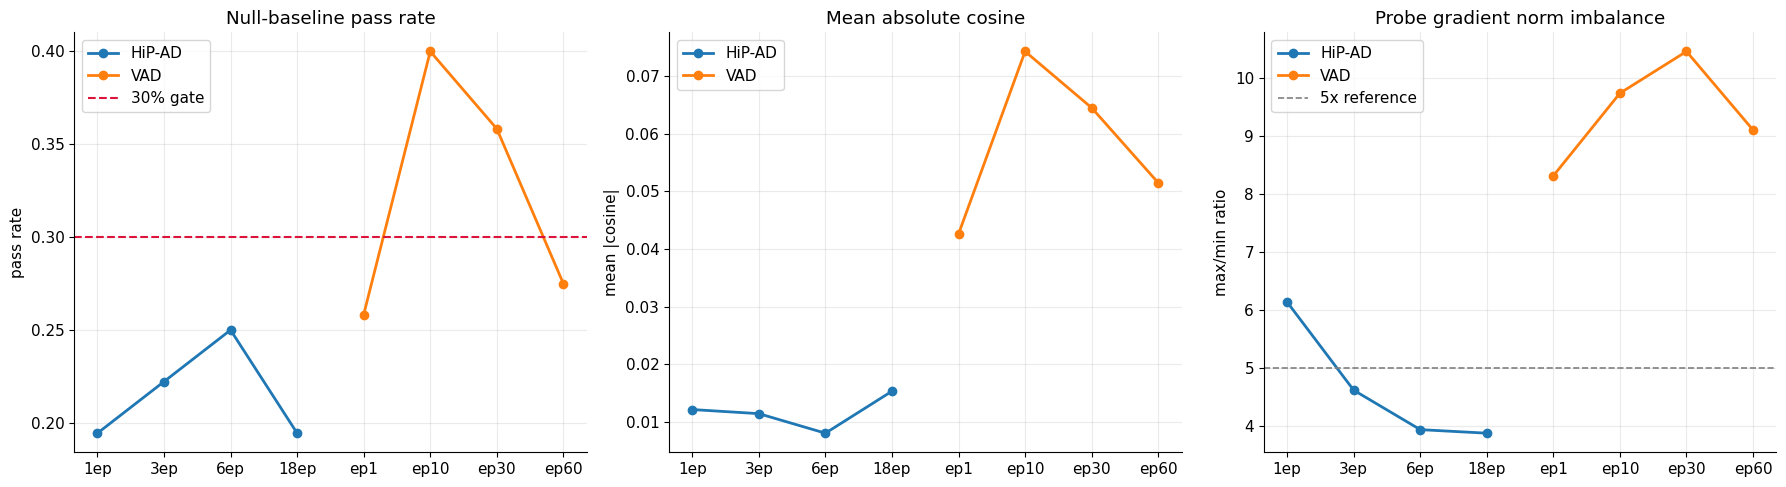

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for model, df in null_ckpt.groupby('model'):
    d = df.sort_values('checkpoint_order')
    axes[0].plot(d['checkpoint'], d['pass_rate'], marker='o', linewidth=2, label=model)
axes[0].axhline(0.30, color='crimson', linestyle='--', linewidth=1.5, label='30% gate')
axes[0].set_title('Null-baseline pass rate')
axes[0].set_ylabel('pass rate')
axes[0].legend()

for model, df in conf_ckpt.groupby('model'):
    d = df.sort_values('checkpoint_order')
    axes[1].plot(d['checkpoint'], d['mean_abs_cos'], marker='o', linewidth=2, label=model)
axes[1].set_title('Mean absolute cosine')
axes[1].set_ylabel('mean |cosine|')
axes[1].legend()

for model, df in probe_norm_ratio.groupby('model'):
    d = df.sort_values('checkpoint_order')
    axes[2].plot(d['checkpoint'], d['max_min_ratio'], marker='o', linewidth=2, label=model)
axes[2].axhline(5.0, color='gray', linestyle='--', linewidth=1.2, label='5x reference')
axes[2].set_title('Probe gradient norm imbalance')
axes[2].set_ylabel('max/min ratio')
axes[2].legend()

plt.tight_layout()
plt.show()

# Appendix.A. HiP-AD diagnostic (legacy)

HiP-AD는 Phase 1에서 이미 “magnitude-dominated, conflict-weak”로 판정되었습니다. Phase 2의 layer-focused 분석도 큰 방향은 같습니다.

이 파트에서는 HiP-AD만 따로 봅니다.

핵심 관찰은 세 가지입니다.

1. null-baseline pass rate가 30% gate 아래입니다.
2. layer conflict ratio는 0.5 근처지만 mean cosine이 매우 작습니다.
3. 1-step probe에서 자기 task는 대부분 좋아지지만, cross-task 효과는 거의 random에 가깝습니다.

In [16]:
def show_model_overview(model):
    print(f'=== {model} overview ===')
    print('\nNull baseline by checkpoint')
    display(null_ckpt[null_ckpt['model'] == model].drop(columns=['model']))
    print('\nLayer conflict by checkpoint')
    display(conf_ckpt[conf_ckpt['model'] == model].drop(columns=['model']))
    print('\nProbe gradient norm ratio')
    display(probe_norm_ratio[probe_norm_ratio['model'] == model].drop(columns=['model']))

show_model_overview('HiP-AD')

=== HiP-AD overview ===

Null baseline by checkpoint


,checkpoint,checkpoint_order,pass_rate
1,1ep,1,0.194444
2,3ep,3,0.222222
3,6ep,6,0.250000
0,18ep,18,0.194444



Layer conflict by checkpoint


,checkpoint,checkpoint_order,cells,mean_conflict,median_conflict,p90_conflict,high_ge_050,mean_cos,mean_abs_cos
1,1ep,1,60,0.464167,0.460,0.551,0.400000,0.009732,0.012156
2,3ep,3,60,0.469333,0.485,0.560,0.400000,0.008591,0.011445
3,6ep,6,60,0.480000,0.500,0.561,0.533333,0.005921,0.008058
0,18ep,18,60,0.458333,0.495,0.561,0.500000,0.012564,0.015335



Probe gradient norm ratio


source_task,checkpoint,checkpoint_order,det,map,motion,plan,max_min_ratio
1,1ep,1,0.462862,0.379266,0.075432,0.434191,6.136133
2,3ep,3,0.451766,0.334752,0.097801,0.430304,4.619248
3,6ep,6,0.466618,0.352624,0.118425,0.356636,3.940214
0,18ep,18,0.655712,0.339011,0.169042,0.318759,3.878979


## A1. HiP-AD null-baseline 해석

HiP-AD의 null-baseline pass rate는 checkpoint별로 약 19-25%입니다. 30% gate를 넘지 않습니다.

이 의미는 중요합니다. conflict ratio만 보면 0.5 근처인 cell들이 있어서 “충돌이 많은 것 아닌가?”라고 볼 수 있습니다. 하지만 null 검정은 그 신호가 noise와 충분히 구분되는지 묻습니다. HiP-AD는 이 기준에서 강하지 않습니다.

따라서 HiP-AD에 대해 “global direction conflict가 핵심 병목”이라고 말하기는 어렵습니다. 더 안전한 해석은 “일부 layer에서 부호 충돌은 있지만, 신호 크기와 통계적 분리도가 약하다”입니다.

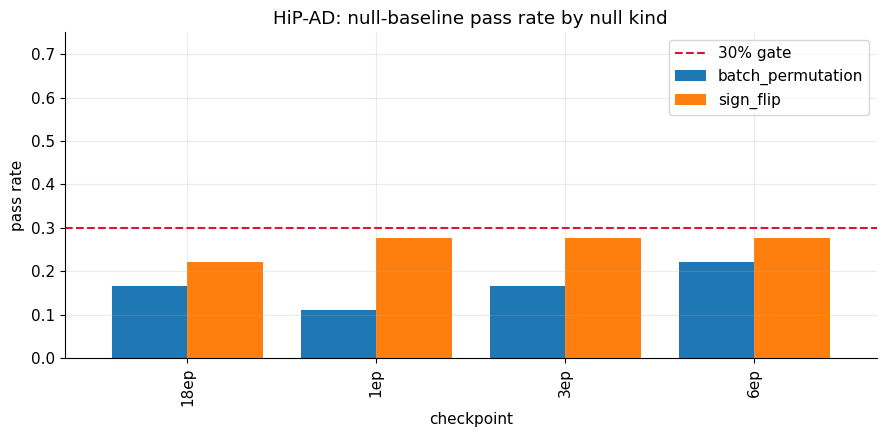

In [17]:
def plot_null_by_kind(model):
    df = null_baseline[null_baseline['model'] == model]
    pivot = (
        df.groupby(['checkpoint', 'checkpoint_order', 'null_kind'])['passes_noise_threshold']
        .mean()
        .reset_index()
        .sort_values('checkpoint_order')
        .pivot(index='checkpoint', columns='null_kind', values='passes_noise_threshold')
    )
    ax = pivot.plot(kind='bar', figsize=(9, 4.5), width=0.8)
    ax.axhline(0.30, color='crimson', linestyle='--', linewidth=1.5, label='30% gate')
    ax.set_title(f'{model}: null-baseline pass rate by null kind')
    ax.set_ylabel('pass rate')
    ax.set_xlabel('checkpoint')
    ax.set_ylim(0, 0.75)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

plot_null_by_kind('HiP-AD')

## A2. HiP-AD conflict의 위치: decoder FFN 계열에 얇게 퍼진다

HiP-AD의 layer conflict는 decoder FFN 계열에 넓게 퍼져 있습니다. 상위 layer는 `dec*_ffn_0_fc1`, `dec*_ffn_0_pre_norm`입니다.

하지만 mean cosine의 절댓값이 작습니다. 즉 “강한 negative alignment”라기보다, 100 batch 중 절반 전후에서 cosine 부호가 음수로 흔들리는 현상에 가깝습니다.

특히 `det-motion`은 평균 conflict가 가장 낮고 mean cosine이 양수 쪽입니다. 이 pair는 direction conflict보다 magnitude imbalance 또는 loss landscape 문제가 더 중요해 보입니다.

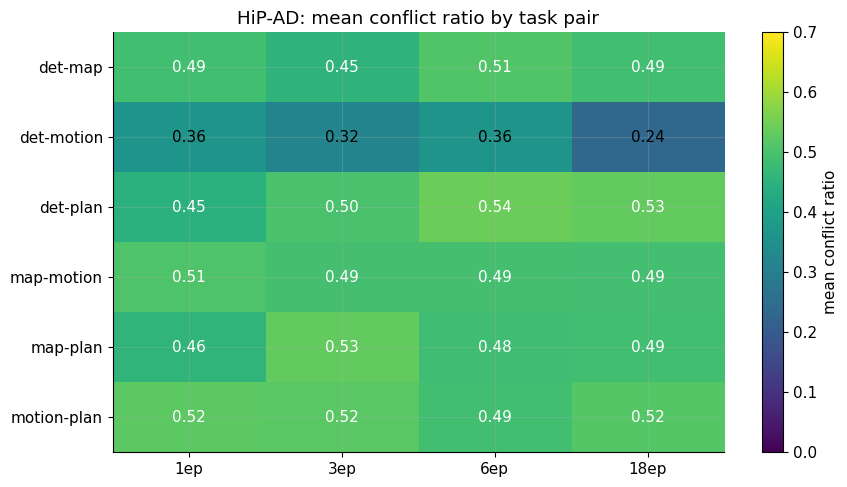

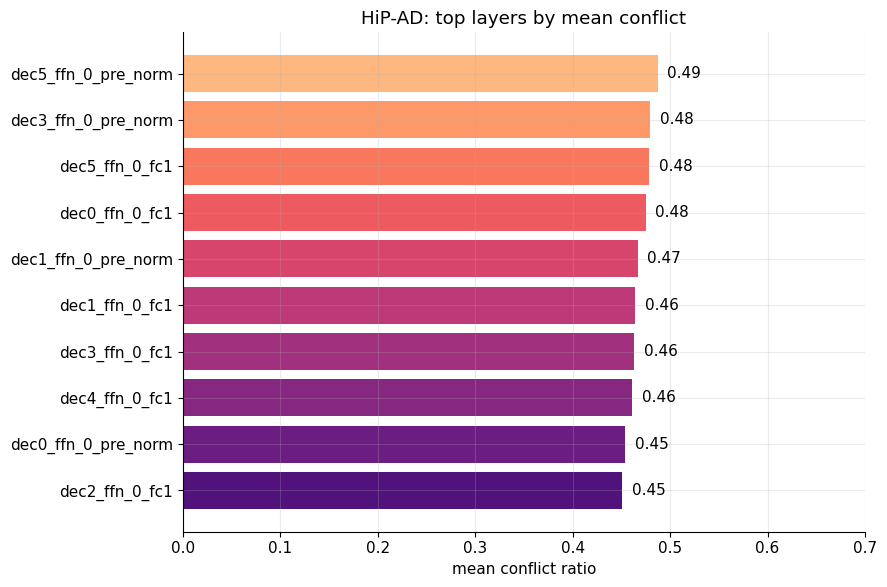

,group,mean_conflict,max_conflict,mean_abs_cos,cells
9,dec5_ffn_0_pre_norm,0.487083,0.61,0.011049,24
6,dec3_ffn_0_pre_norm,0.479583,0.58,0.014802,24
8,dec5_ffn_0_fc1,0.478333,0.58,0.005726,24
0,dec0_ffn_0_fc1,0.475000,0.63,0.016782,24
3,dec1_ffn_0_pre_norm,0.466667,0.57,0.014121,24
2,dec1_ffn_0_fc1,0.464167,0.59,0.008639,24
5,dec3_ffn_0_fc1,0.463333,0.57,0.007816,24
7,dec4_ffn_0_fc1,0.460833,0.58,0.005024,24
1,dec0_ffn_0_pre_norm,0.454167,0.64,0.027524,24
4,dec2_ffn_0_fc1,0.450417,0.56,0.006001,24


In [18]:
def plot_pair_heatmap(model):
    df = real_layer_conflict[real_layer_conflict['model'] == model].copy()
    df['pair'] = df['task_a'] + '-' + df['task_b']
    pair_summary = (
        df.groupby(['checkpoint', 'checkpoint_order', 'pair'])['conflict_ratio']
        .mean()
        .reset_index()
    )
    pivot = pair_summary.pivot_table(index='pair', columns='checkpoint', values='conflict_ratio')
    ordered_cols = sorted(pivot.columns, key=checkpoint_sort_key)
    pivot = pivot.reindex(TASK_PAIR_LABELS)[ordered_cols]

    fig, ax = plt.subplots(figsize=(9, 5))
    im = ax.imshow(pivot.values, vmin=0.0, vmax=0.7, cmap='viridis', aspect='auto')
    ax.set_title(f'{model}: mean conflict ratio by task pair')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            value = pivot.values[i, j]
            if not np.isnan(value):
                ax.text(j, i, f'{value:.2f}', ha='center', va='center', color='white' if value > 0.42 else 'black')
    fig.colorbar(im, ax=ax, label='mean conflict ratio')
    plt.tight_layout()
    plt.show()


def plot_top_layers(model, n=12):
    df = real_layer_conflict[real_layer_conflict['model'] == model]
    layer_summary = (
        df.groupby('group')
        .agg(
            mean_conflict=('conflict_ratio', 'mean'),
            max_conflict=('conflict_ratio', 'max'),
            mean_abs_cos=('mean_cos', lambda s: s.abs().mean()),
            cells=('conflict_ratio', 'size'),
        )
        .reset_index()
        .sort_values('mean_conflict', ascending=True)
        .tail(n)
    )
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(layer_summary['group'], layer_summary['mean_conflict'], color=plt.cm.magma(np.linspace(0.25, 0.85, len(layer_summary))))
    ax.set_title(f'{model}: top layers by mean conflict')
    ax.set_xlabel('mean conflict ratio')
    ax.set_xlim(0, max(0.7, layer_summary['mean_conflict'].max() + 0.05))
    for y, value in enumerate(layer_summary['mean_conflict']):
        ax.text(value + 0.01, y, f'{value:.2f}', va='center')
    plt.tight_layout()
    plt.show()
    display(layer_summary.sort_values('mean_conflict', ascending=False))

plot_pair_heatmap('HiP-AD')
plot_top_layers('HiP-AD')

## A3. HiP-AD 1-step probe: task별 해석

이제 1-step probe를 task별로 봅니다. 표와 그림에서 `source_task`는 gradient step을 제공한 task이고, `target_task`는 그 step 이후 loss 변화를 측정한 task입니다.

### det source

`det → det` helpful ratio는 매우 높습니다. det gradient는 자기 loss를 잘 줄입니다. 하지만 `det → map`, `det → motion`, `det → plan`은 0.47-0.50 근처입니다. 즉 det gradient가 다른 task를 안정적으로 돕는다고 보기 어렵습니다.

### map source

`map → map`도 diagonal은 높습니다. 그러나 cross-task는 거의 random입니다. `map → plan`만 약간 0.5를 넘지만 효과 크기는 작습니다.

### motion source

motion은 HiP-AD에서 가장 조심해야 하는 task입니다. gradient norm이 작고, `motion → motion` diagonal helpful ratio도 다른 task보다 낮습니다. 그럼에도 `motion → det`가 cross-task 중 가장 높게 나옵니다. 하지만 motion gradient 자체가 작고 noise-dominated일 가능성이 있어, 이 결과를 강한 transfer라고 해석하면 안 됩니다.

### plan source

`plan → plan`은 잘 내려갑니다. cross-task는 대체로 0.5 주변입니다. plan gradient도 자기 task 중심의 성격이 강합니다.

정리하면, HiP-AD의 1-step probe는 “각 task는 자기 loss를 줄이는 방향은 갖고 있지만, task 간 안정적인 positive transfer는 약하다”입니다.

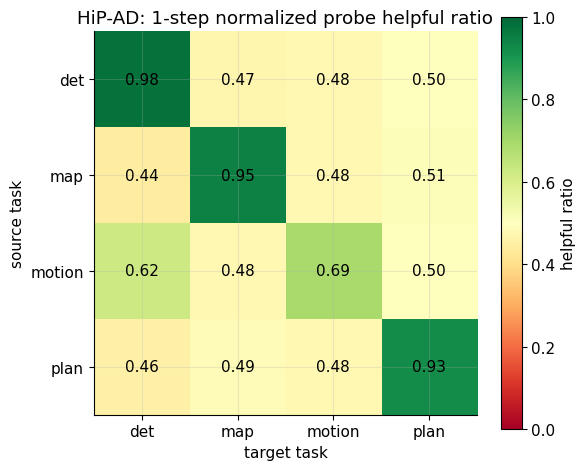

,source_task,target_task,rows,mean_delta,helpful,harmful,mean_grad_norm
0,det,det,4000,-0.000466,0.98025,0.01850,0.509240
1,det,map,4000,0.000001,0.47150,0.52650,0.509240
2,det,motion,4000,0.000113,0.47850,0.52150,0.509240
3,det,plan,4000,0.000005,0.49625,0.50300,0.509240
4,map,det,4000,0.000011,0.44400,0.52500,0.351413
5,map,map,4000,-0.000340,0.94625,0.05275,0.351413
6,map,motion,4000,0.000034,0.47825,0.52075,0.351413
7,map,plan,4000,0.000005,0.51150,0.48575,0.351413
8,motion,det,4000,-0.000064,0.62225,0.35500,0.115175
9,motion,map,4000,0.000003,0.47925,0.51650,0.115175


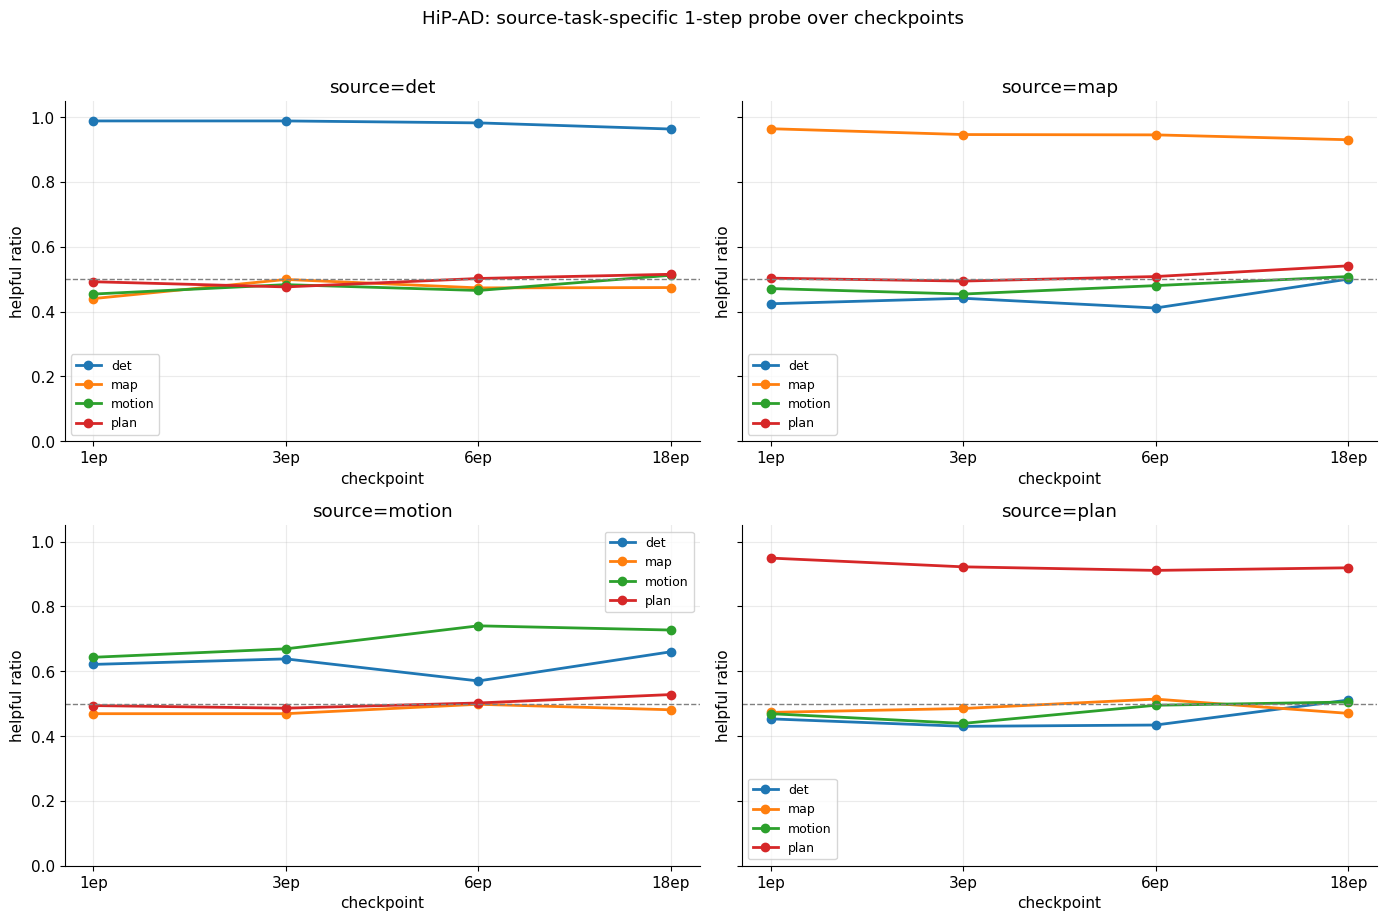

In [19]:
def model_probe_summary(model):
    df = probe_st[probe_st['model'] == model]
    overall = (
        df.groupby(['source_task', 'target_task'])
        .agg(
            rows=('rows', 'sum'),
            mean_delta=('mean_delta', 'mean'),
            helpful=('helpful', 'mean'),
            harmful=('harmful', 'mean'),
            mean_grad_norm=('mean_grad_norm', 'mean'),
        )
        .reset_index()
    )
    return overall

def plot_helpful_matrix(model):
    overall = model_probe_summary(model)
    pivot = overall.pivot(index='source_task', columns='target_task', values='helpful').reindex(index=TASKS, columns=TASKS)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(pivot.values, vmin=0.0, vmax=1.0, cmap='RdYlGn', aspect='equal')
    ax.set_title(f'{model}: 1-step normalized probe helpful ratio')
    ax.set_xticks(range(len(TASKS)))
    ax.set_xticklabels(TASKS)
    ax.set_yticks(range(len(TASKS)))
    ax.set_yticklabels(TASKS)
    ax.set_xlabel('target task')
    ax.set_ylabel('source task')
    for i in range(len(TASKS)):
        for j in range(len(TASKS)):
            value = pivot.values[i, j]
            ax.text(j, i, f'{value:.2f}', ha='center', va='center', color='black')
    fig.colorbar(im, ax=ax, label='helpful ratio')
    plt.tight_layout()
    plt.show()
    display(overall.sort_values(['source_task', 'target_task']))


def plot_source_task_probe_by_checkpoint(model):
    df = probe_st[probe_st['model'] == model]
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
    axes = axes.ravel()
    for ax, source in zip(axes, TASKS):
        src = df[df['source_task'] == source]
        for target in TASKS:
            d = src[src['target_task'] == target].sort_values('checkpoint_order')
            ax.plot(d['checkpoint'], d['helpful'], marker='o', linewidth=2, label=target)
        ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
        ax.set_title(f'source={source}')
        ax.set_xlabel('checkpoint')
        ax.set_ylabel('helpful ratio')
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=9)
    fig.suptitle(f'{model}: source-task-specific 1-step probe over checkpoints', y=1.02)
    plt.tight_layout()
    plt.show()

plot_helpful_matrix('HiP-AD')
plot_source_task_probe_by_checkpoint('HiP-AD')

## A4. HiP-AD 결론

HiP-AD의 세부 분석 결론은 다음입니다.

1. direction conflict는 전역적으로 약합니다. null-baseline pass가 30% 아래이고 mean cosine도 거의 0입니다.
2. decoder FFN 계열에서 부호 충돌은 반복적으로 보이지만, 효과 크기는 작습니다.
3. 1-step probe에서는 diagonal이 강하고 off-diagonal은 random에 가깝습니다.
4. motion task는 gradient norm이 작고 probe 안정성도 낮아, motion 관련 affinity는 특히 조심해서 해석해야 합니다.

따라서 HiP-AD의 algorithmic bottleneck은 direction surgery보다 **task별 gradient magnitude 조절과 training stage별 scheduling** 쪽입니다.

# Appendix.B. VAD diagnostic (legacy)

VAD는 HiP-AD와 같은 결론으로만 묶으면 중요한 차이를 놓칩니다.

VAD도 magnitude imbalance가 큽니다. 오히려 HiP-AD보다 더 큽니다. 하지만 동시에 일부 encoder layer에서 direction-conflict 신호가 HiP-AD보다 더 선명합니다.

핵심 관찰은 네 가지입니다.

1. null-baseline pass rate가 전체 32.3%로 30% gate를 넘습니다.
2. 다만 이 pass는 `sign_flip` 쪽에 많이 몰려 있고, `batch_permutation`은 낮습니다.
3. conflict top cell은 `map-plan`과 early/mid BEV encoder layer에서 나옵니다.
4. 1-step probe cross-task helpful rate가 HiP-AD보다 약간 높지만, delta 크기는 여전히 작습니다.

=== VAD overview ===

Null baseline by checkpoint


,checkpoint,checkpoint_order,pass_rate
4,ep1,1,0.258333
5,ep10,10,0.400000
6,ep30,30,0.358333
7,ep60,60,0.275000



Layer conflict by checkpoint


,checkpoint,checkpoint_order,cells,mean_conflict,median_conflict,p90_conflict,high_ge_050,mean_cos,mean_abs_cos
4,ep1,1,60,0.415333,0.430,0.520,0.183333,0.039709,0.042593
5,ep10,10,60,0.353500,0.355,0.512,0.183333,0.071965,0.074240
6,ep30,30,60,0.355167,0.380,0.510,0.150000,0.062025,0.064468
7,ep60,60,60,0.414000,0.435,0.533,0.250000,0.040123,0.051467



Probe gradient norm ratio


source_task,checkpoint,checkpoint_order,det,map,motion,plan,max_min_ratio
4,ep1,1,0.740447,0.289444,0.100236,0.089115,8.308940
5,ep10,10,0.901549,0.312537,0.092653,0.129342,9.730408
6,ep30,30,0.901407,0.285992,0.086264,0.113191,10.449424
7,ep60,60,0.732850,0.259834,0.080560,0.096499,9.096961


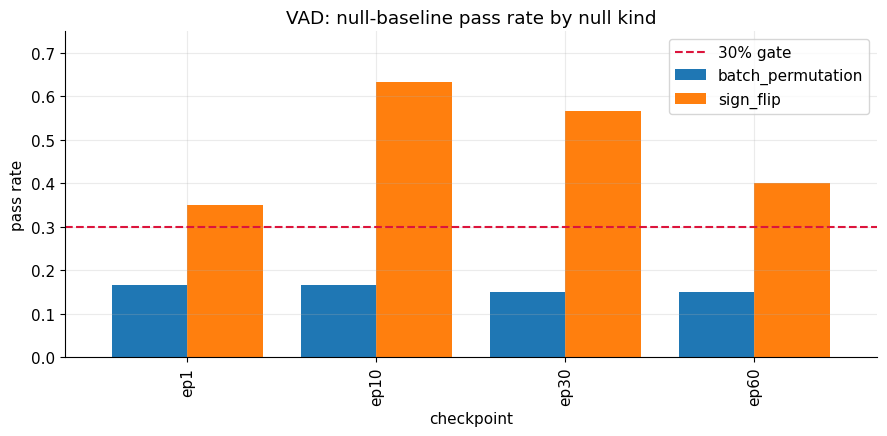

In [20]:
show_model_overview('VAD')
plot_null_by_kind('VAD')

## B1. VAD null-baseline 해석

VAD는 null-baseline overall pass rate가 30%를 넘습니다. 이것은 HiP-AD와 다른 지점입니다.

하지만 자세히 보면 `sign_flip` pass가 높고 `batch_permutation` pass는 낮습니다. 즉 평균 cosine이 0에서 벗어난 cell은 많지만, batch permutation 기준으로 robust한 구조적 신호는 제한적입니다.

따라서 VAD는 “conflict signal이 있다”고 해야 하지만, “전역적으로 강한 conflict 구조가 지배한다”고 말하기보다는 **local direction bias가 일부 layer와 pair에서 나타난다**고 말하는 것이 안전합니다.

## B2. VAD conflict 위치: BEV encoder shared layer가 핵심

VAD의 top conflict는 대부분 early/mid BEV encoder shared layer에서 나옵니다.

대표적인 cell은 다음입니다.

- `ep60 / map-plan / enc1_spatial_cross_attention`: conflict ratio 0.65, mean cosine -0.173
- `ep60 / map-plan / enc0_ffn`: conflict ratio 0.64, mean cosine -0.072
- `ep1 / det-plan / enc0_temporal_self_attention`: conflict ratio 0.61

HiP-AD의 top cell은 conflict ratio는 높아도 mean cosine이 작았는데, VAD는 일부 cell에서 mean cosine의 절댓값도 더 큽니다. 그래서 VAD의 direction-conflict signal은 HiP-AD보다 논문에서 다루기 좋습니다.

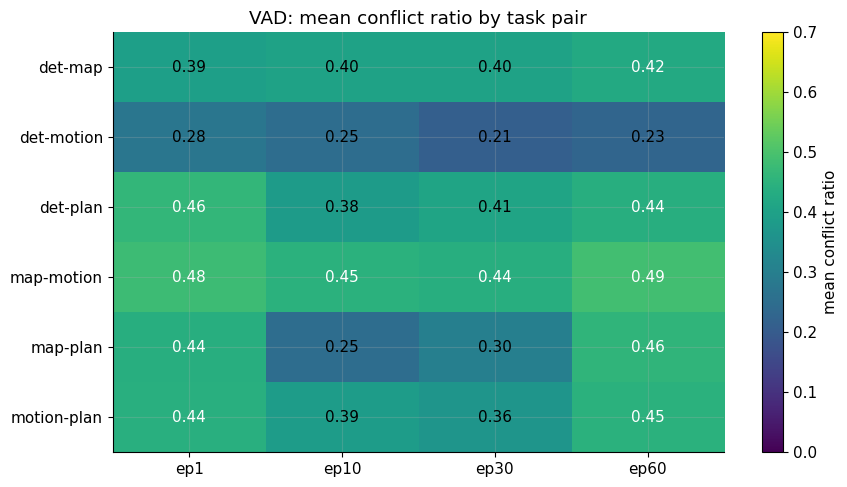

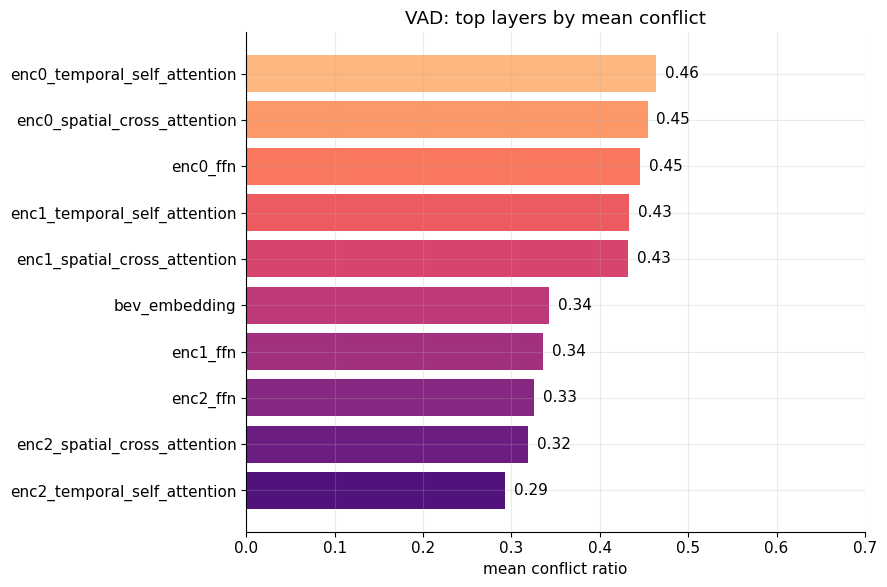

,group,mean_conflict,max_conflict,mean_abs_cos,cells
3,enc0_temporal_self_attention,0.464167,0.61,0.033599,24
2,enc0_spatial_cross_attention,0.454167,0.59,0.036315,24
1,enc0_ffn,0.445833,0.64,0.058918,24
6,enc1_temporal_self_attention,0.432917,0.57,0.037872,24
5,enc1_spatial_cross_attention,0.431667,0.65,0.125355,24
0,bev_embedding,0.342917,0.53,0.031559,24
4,enc1_ffn,0.335833,0.50,0.091113,24
7,enc2_ffn,0.325417,0.52,0.035989,24
8,enc2_spatial_cross_attention,0.318750,0.47,0.076921,24
9,enc2_temporal_self_attention,0.293333,0.49,0.054278,24


,checkpoint,task_a,task_b,group,conflict_ratio,mean_cos,n_valid
465,ep60,map,plan,enc1_spatial_cross_attention,0.65,-0.173075,100
461,ep60,map,plan,enc0_ffn,0.64,-0.071503,100
263,ep1,det,plan,enc0_temporal_self_attention,0.61,-0.018339,100
271,ep1,map,motion,enc0_ffn,0.60,-0.031680,100
441,ep60,det,plan,enc0_ffn,0.59,-0.018969,100
462,ep60,map,plan,enc0_spatial_cross_attention,0.59,-0.016423,100
466,ep60,map,plan,enc1_temporal_self_attention,0.57,-0.012029,100
303,ep10,det,map,enc0_temporal_self_attention,0.57,-0.007267,100
456,ep60,map,motion,enc1_temporal_self_attention,0.56,-0.008956,100
395,ep30,map,motion,enc1_spatial_cross_attention,0.56,-0.033361,100


In [21]:
plot_pair_heatmap('VAD')
plot_top_layers('VAD')

vad_top = (
    real_layer_conflict[real_layer_conflict['model'] == 'VAD']
    .sort_values('conflict_ratio', ascending=False)
    [['checkpoint', 'task_a', 'task_b', 'group', 'conflict_ratio', 'mean_cos', 'n_valid']]
    .head(12)
)
display(vad_top)

## B3. VAD 1-step probe: task별 해석

VAD의 1-step probe는 HiP-AD보다 cross-task helpful ratio가 전반적으로 약간 높습니다. 하지만 gradient norm imbalance가 매우 크므로, 이 결과는 magnitude 관점과 같이 봐야 합니다.

### det source

`det` gradient norm이 가장 큽니다. `det → det`는 diagonal로 잘 작동합니다. Cross-task에서는 `det → motion`이 비교적 높고, `det → map`, `det → plan`도 0.54 근처입니다. 즉 det direction은 HiP-AD보다 다른 task에 덜 해롭고 약간 도움이 되는 bias를 보입니다. 그러나 det norm이 압도적으로 크기 때문에, 학습에서는 det가 다른 task를 압도할 위험도 큽니다.

### map source

`map → map`은 diagonal로 잘 내려갑니다. Cross-task에서는 `map → det`, `map → plan`이 0.55 이상입니다. VAD에서는 map gradient가 다른 task와 완전히 분리되어 있지는 않고, 일부 shared BEV representation을 함께 움직이는 것으로 보입니다.

### motion source

motion은 gradient norm이 가장 작습니다. 그런데 `motion → det` helpful ratio가 높게 나옵니다. 이것은 HiP-AD에서도 비슷하게 보인 패턴입니다. 다만 motion norm이 작기 때문에 실제 optimization에서 motion gradient가 det를 의미 있게 밀어준다고 해석하기보다는, 작은 step 기준에서 det loss가 내려가는 방향과 일부 정렬되어 있다고 보는 정도가 안전합니다.

### plan source

plan도 norm이 작습니다. `plan → map`, `plan → det`가 0.55 이상으로 나오며, HiP-AD보다 cross-task helpful이 낫습니다. 하지만 `plan → plan` diagonal helpful이 아주 높지는 않으므로, plan loss landscape도 완전히 안정적인 편은 아닙니다.

정리하면, VAD는 cross-task helpful ratio가 HiP-AD보다 조금 더 우호적입니다. 그러나 det norm이 매우 크고 motion/plan norm이 작아서, 최종 병목은 여전히 magnitude imbalance입니다.

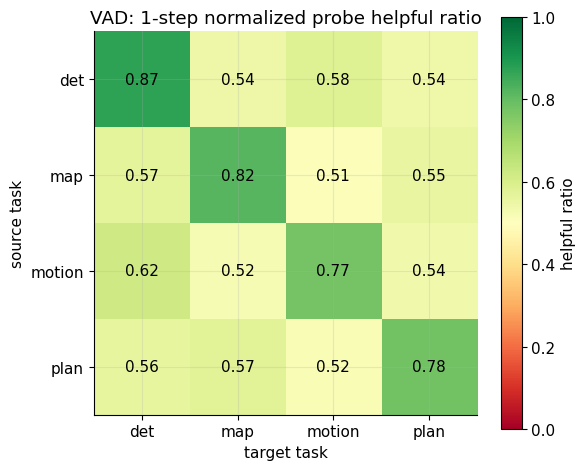

,source_task,target_task,rows,mean_delta,helpful,harmful,mean_grad_norm
0,det,det,4000,-0.000685,0.87425,0.12575,0.819063
1,det,map,4000,-0.000044,0.54300,0.45625,0.819063
2,det,motion,4000,-0.000010,0.58450,0.41475,0.819063
3,det,plan,4000,0.000003,0.54100,0.45875,0.819063
4,map,det,4000,0.000260,0.56725,0.43150,0.286951
5,map,map,4000,-0.000589,0.81900,0.18025,0.286951
6,map,motion,4000,0.000005,0.50850,0.49125,0.286951
7,map,plan,4000,-0.000007,0.55500,0.44475,0.286951
8,motion,det,4000,0.000158,0.61825,0.38100,0.089928
9,motion,map,4000,-0.000013,0.52150,0.47775,0.089928


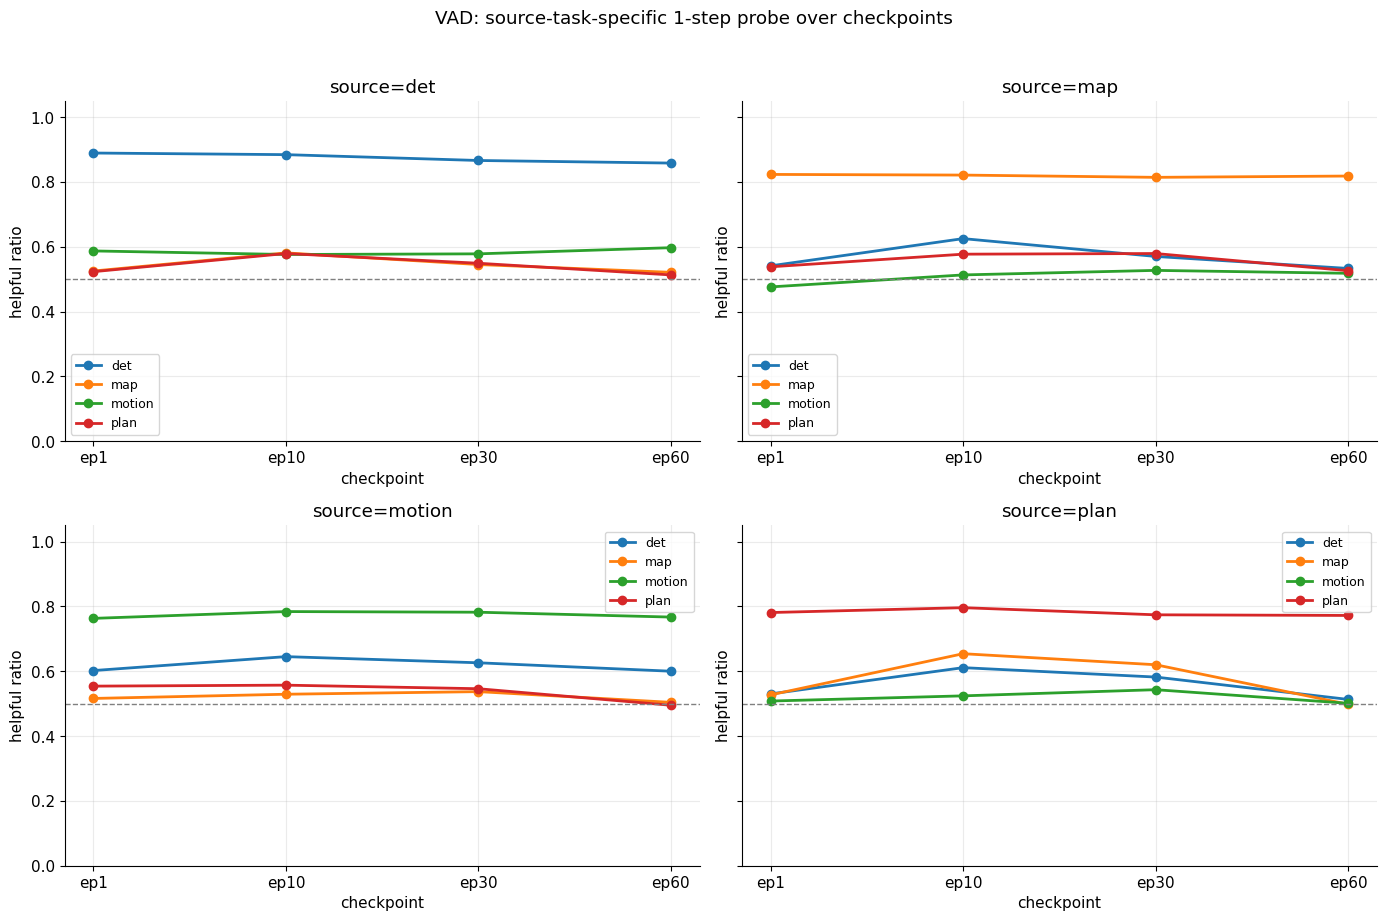

In [22]:
plot_helpful_matrix('VAD')
plot_source_task_probe_by_checkpoint('VAD')

## B4. VAD 결론

VAD의 세부 분석 결론은 다음입니다.

1. HiP-AD보다 direction-conflict signal이 더 분명합니다.
2. 특히 `map-plan`과 `enc0/enc1` BEV encoder 계열 layer가 중요합니다.
3. 하지만 gradient norm imbalance가 매우 큽니다. det가 크고 motion/plan이 작습니다.
4. 1-step probe에서는 cross-task helpful이 약간 우호적이지만, 평균 delta가 작기 때문에 강한 transfer라고 말하기는 어렵습니다.

따라서 VAD에 대해서는 “magnitude-dominated + local direction-conflict”라고 요약하는 것이 가장 정확합니다.

# Appendix.C. Task-pair helpful matrix (Appendix only)

앞에서는 모델별로 probe를 봤습니다. 이제 task별 관점으로 두 모델을 직접 비교합니다.

각 source task에 대해 질문은 다음입니다.

- 이 task의 gradient가 자기 loss를 잘 줄이는가?
- 다른 task loss에도 도움이 되는가?
- 그 효과가 HiP-AD와 VAD에서 어떻게 다른가?

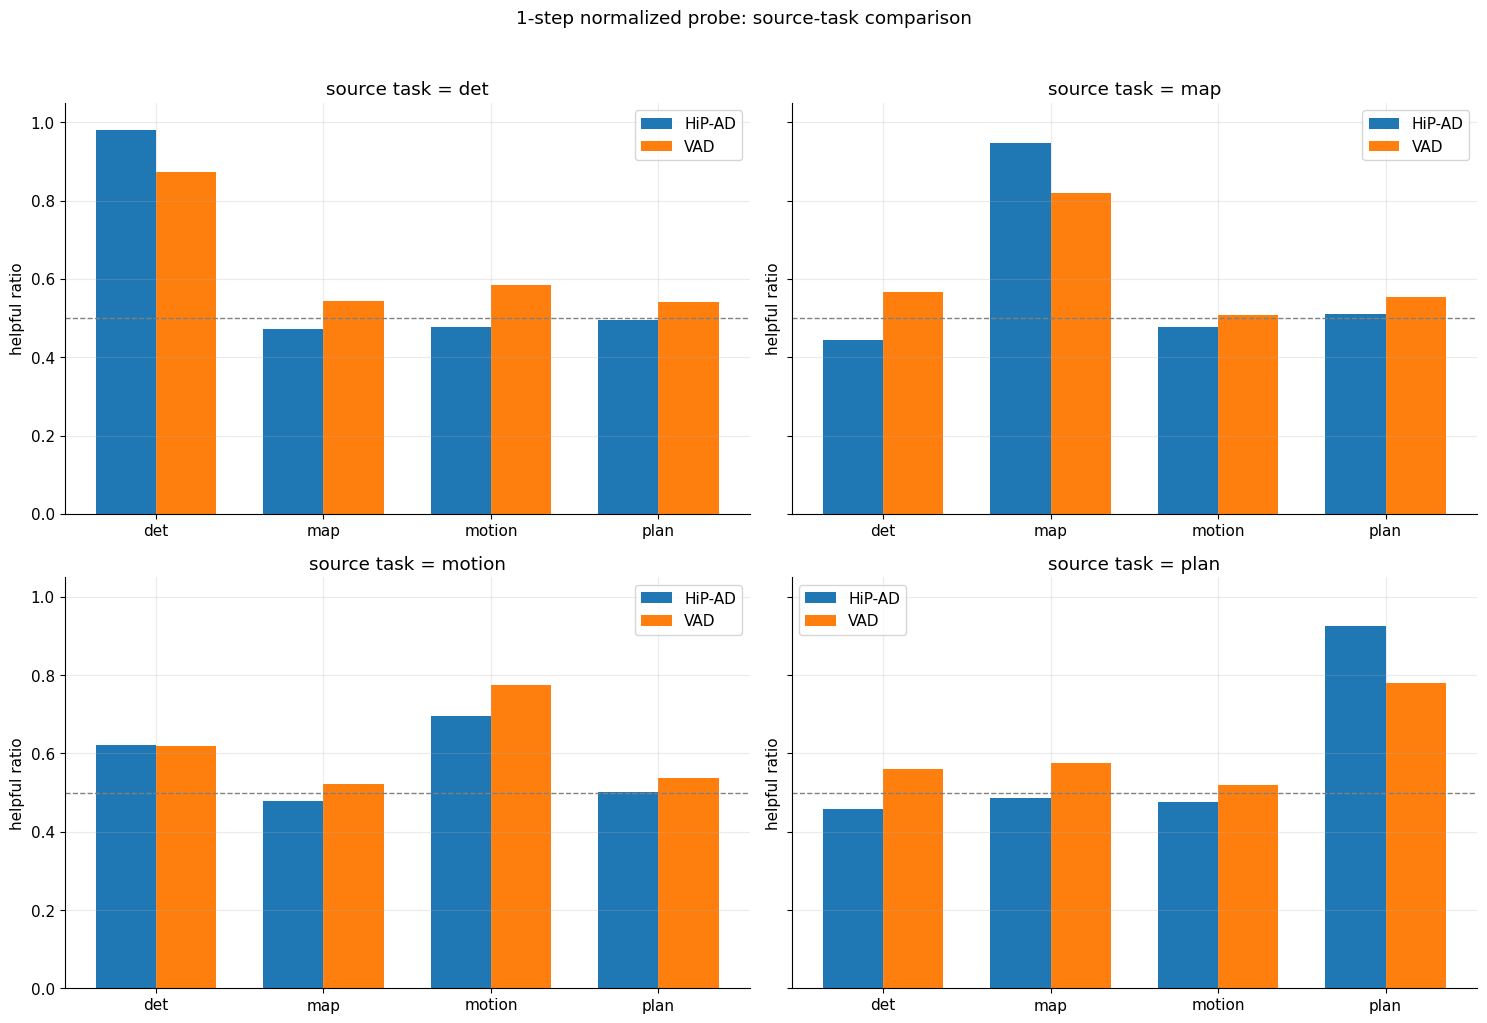

,model,source_task,target_task,helpful,harmful,mean_delta,mean_grad_norm
0,HiP-AD,det,det,0.98025,0.01850,-0.000466,0.509240
1,HiP-AD,det,map,0.47150,0.52650,0.000001,0.509240
2,HiP-AD,det,motion,0.47850,0.52150,0.000113,0.509240
3,HiP-AD,det,plan,0.49625,0.50300,0.000005,0.509240
16,VAD,det,det,0.87425,0.12575,-0.000685,0.819063
17,VAD,det,map,0.54300,0.45625,-0.000044,0.819063
18,VAD,det,motion,0.58450,0.41475,-0.000010,0.819063
19,VAD,det,plan,0.54100,0.45875,0.000003,0.819063
4,HiP-AD,map,det,0.44400,0.52500,0.000011,0.351413
5,HiP-AD,map,map,0.94625,0.05275,-0.000340,0.351413


In [23]:
probe_overall = (
    probe_st.groupby(['model', 'source_task', 'target_task'])
    .agg(
        helpful=('helpful', 'mean'),
        harmful=('harmful', 'mean'),
        mean_delta=('mean_delta', 'mean'),
        mean_grad_norm=('mean_grad_norm', 'mean'),
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
axes = axes.ravel()
for ax, source in zip(axes, TASKS):
    d = probe_overall[probe_overall['source_task'] == source]
    x = np.arange(len(TASKS))
    width = 0.36
    for offset, model in [(-width/2, 'HiP-AD'), (width/2, 'VAD')]:
        vals = d[d['model'] == model].set_index('target_task').reindex(TASKS)['helpful'].values
        ax.bar(x + offset, vals, width=width, label=model)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'source task = {source}')
    ax.set_xticks(x)
    ax.set_xticklabels(TASKS)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('helpful ratio')
    ax.legend()

fig.suptitle('1-step normalized probe: source-task comparison', y=1.02)
plt.tight_layout()
plt.show()

display(probe_overall.sort_values(['source_task', 'model', 'target_task']))

## C1. det source 비교

`det`는 두 모델 모두 norm이 큰 source입니다.

- HiP-AD: `det → det`는 매우 높지만 cross-task는 거의 0.5입니다.
- VAD: `det → motion`, `det → map`, `det → plan`이 HiP-AD보다 높습니다.

해석: VAD의 det gradient는 shared BEV representation을 통해 다른 task에도 약간 더 우호적입니다. 하지만 det norm이 크기 때문에, rescaling 없이 두면 다른 task를 압도할 가능성이 큽니다.

## C2. map source 비교

- HiP-AD: `map → map`은 높지만 cross-task는 약합니다.
- VAD: `map → det`, `map → plan`이 조금 더 높습니다.

해석: VAD의 map gradient는 HiP-AD보다 shared encoder 표현을 더 같이 움직이는 것으로 보입니다. 하지만 `map → motion`은 여전히 약합니다.

## C3. motion source 비교

motion은 두 모델 모두 norm이 작습니다.

- HiP-AD: `motion → motion` diagonal도 다른 task보다 낮고, `motion → det`만 상대적으로 높습니다.
- VAD: `motion → det`가 비슷하게 높고, 다른 target도 HiP-AD보다 약간 낫습니다.

해석: motion gradient는 작고 불안정합니다. 따라서 motion 관련 probe는 “강한 transfer”라기보다 “작은 step에서 우연히 또는 약하게 det와 정렬되는 구간이 있다” 정도로 봐야 합니다.

## C4. plan source 비교

- HiP-AD: `plan → plan`은 높지만 cross-task는 거의 random입니다.
- VAD: `plan → map`, `plan → det`가 더 높습니다.

해석: VAD의 plan은 HiP-AD보다 cross-task alignment가 조금 더 낫지만, plan norm이 작아 실제 학습 영향은 제한될 수 있습니다.

# Appendix.D. Distribution / correlation (legacy)

이 파트는 최종 결론을 강화하기 위한 보조 축입니다.

- Distribution은 cosine 평균이 대표값으로 적절한지 확인합니다.
- Correlation은 cosine이 실제 1-step loss 변화량을 설명하는지 확인합니다.

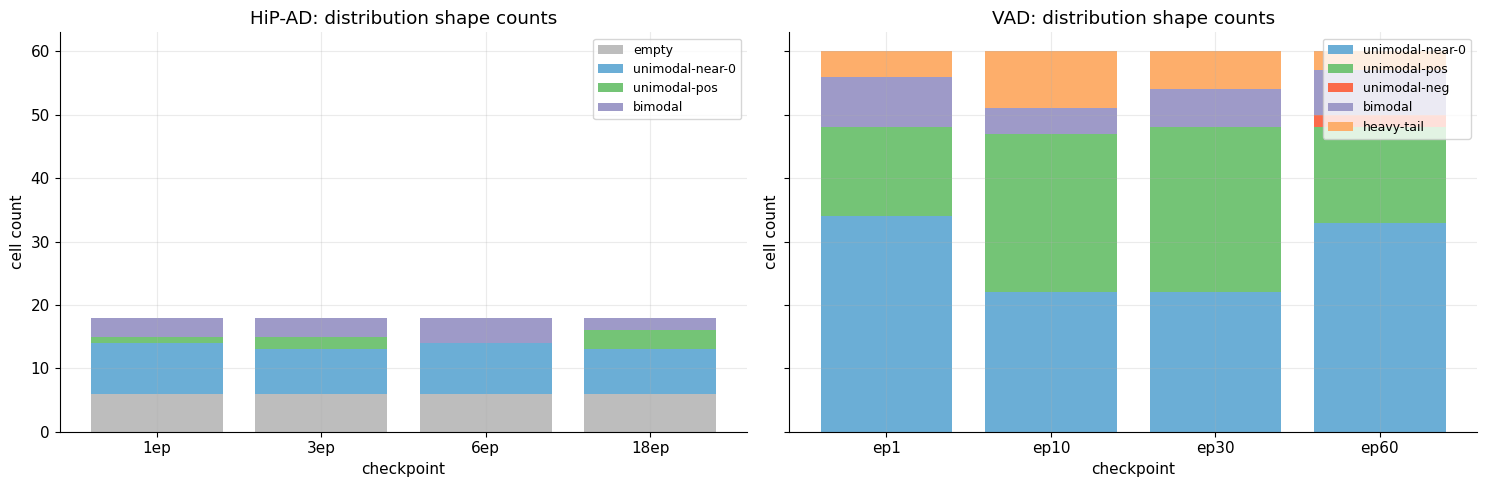

,model,checkpoint,checkpoint_order,rows,mean_abs_pearson,max_abs_pearson,ge_03,mean_helpful
1,HiP-AD,1ep,1,120,0.086052,0.290111,0.000000,0.471417
2,HiP-AD,3ep,3,120,0.087289,0.324500,0.016667,0.461167
3,HiP-AD,6ep,6,120,0.077927,0.238610,0.000000,0.488000
0,HiP-AD,18ep,18,120,0.086002,0.413558,0.008333,0.508083
4,VAD,ep1,1,120,0.120534,0.611961,0.083333,0.524333
5,VAD,ep10,10,120,0.131630,0.649021,0.108333,0.559833
6,VAD,ep30,30,120,0.101796,0.576016,0.050000,0.534167
7,VAD,ep60,60,120,0.125951,0.573367,0.108333,0.515917


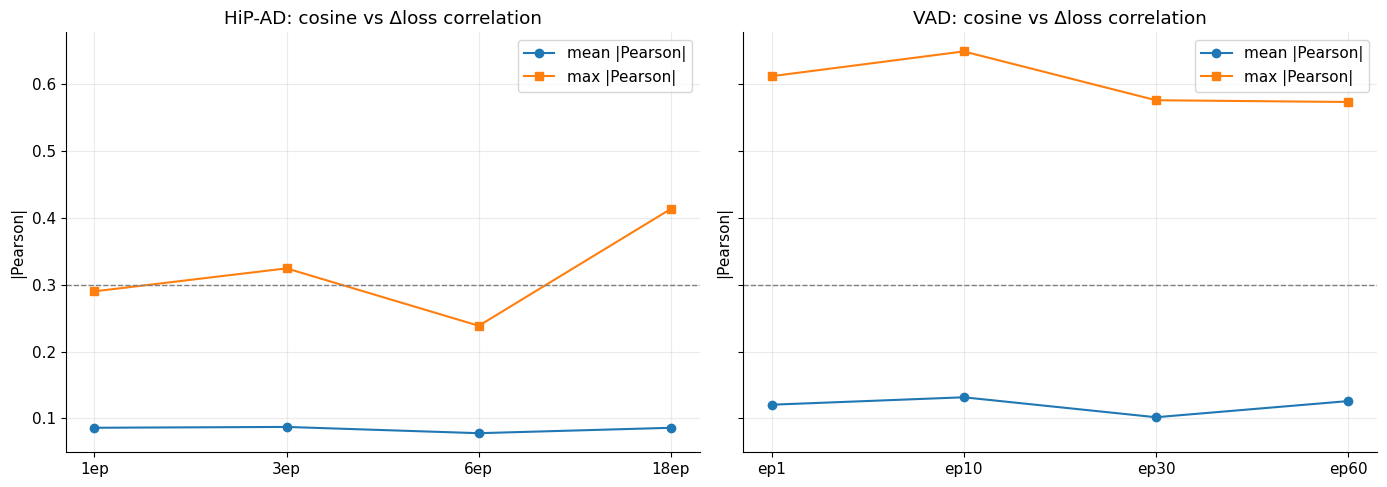

In [24]:
shape_order = ['empty', 'unimodal-near-0', 'unimodal-pos', 'unimodal-neg', 'bimodal', 'heavy-tail']
colors = {
    'empty': '#bdbdbd',
    'unimodal-near-0': '#6baed6',
    'unimodal-pos': '#74c476',
    'unimodal-neg': '#fb6a4a',
    'bimodal': '#9e9ac8',
    'heavy-tail': '#fdae6b',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, (model, df) in zip(axes, distribution.groupby('model')):
    pivot = (
        df.groupby(['checkpoint', 'checkpoint_order', 'shape_label'])
        .size()
        .reset_index(name='n')
        .pivot_table(index='checkpoint', columns='shape_label', values='n', fill_value=0)
    )
    pivot = pivot.reindex(sorted(pivot.index, key=checkpoint_sort_key))
    present = [s for s in shape_order if s in pivot.columns]
    bottom = np.zeros(len(pivot))
    for shape in present:
        values = pivot[shape].values
        ax.bar(pivot.index, values, bottom=bottom, label=shape, color=colors.get(shape))
        bottom += values
    ax.set_title(f'{model}: distribution shape counts')
    ax.set_xlabel('checkpoint')
    ax.set_ylabel('cell count')
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

raw_corr = correlation[(correlation['steps'] == 1) & (correlation['variant'] == 'raw')].copy()
corr_summary = (
    raw_corr.groupby(['model', 'checkpoint', 'checkpoint_order'])
    .agg(
        rows=('pearson', 'size'),
        mean_abs_pearson=('pearson', lambda s: s.abs().mean()),
        max_abs_pearson=('pearson', lambda s: s.abs().max()),
        ge_03=('pearson', lambda s: (s.abs() >= 0.30).mean()),
        mean_helpful=('helpful_ratio', 'mean'),
    )
    .reset_index()
    .sort_values(['model', 'checkpoint_order'])
)

display(corr_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (model, df) in zip(axes, corr_summary.groupby('model')):
    d = df.sort_values('checkpoint_order')
    ax.plot(d['checkpoint'], d['mean_abs_pearson'], marker='o', label='mean |Pearson|')
    ax.plot(d['checkpoint'], d['max_abs_pearson'], marker='s', label='max |Pearson|')
    ax.axhline(0.30, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'{model}: cosine vs Δloss correlation')
    ax.set_ylabel('|Pearson|')
    ax.legend()

plt.tight_layout()
plt.show()

## D1. Distribution 해석

HiP-AD는 empty cell이 있습니다. 이는 pseudo-shared group, 즉 한 task의 gradient가 해당 group을 사실상 지나가지 않는 경우입니다. 이런 cell은 cosine을 task interaction으로 해석하면 안 됩니다.

VAD는 empty가 없고, `unimodal-near-0`, `unimodal-pos`, 일부 `bimodal/heavy-tail`이 나타납니다. 특히 VAD의 bimodal/heavy-tail은 top conflict cell을 해석할 때 평균만 보면 위험할 수 있음을 알려줍니다.

## D2. Correlation 해석

HiP-AD는 cosine과 loss delta의 상관이 약합니다. 평균 |Pearson|이 약 0.08이고, 큰 상관은 드뭅니다.

VAD는 peak correlation이 더 큽니다. 일부 cell은 |Pearson|이 0.6 근처까지 올라갑니다. 그러나 평균은 0.10-0.13 수준이라 sparse signal입니다.

즉 VAD에는 direction-aware analysis 가치가 있지만, 여전히 전체 최적화 병목은 magnitude imbalance 쪽입니다.

# Appendix.E. Affinity / heavy-tail / CI / self-violation (legacy)

이 섹션은 `tools/gradient_analysis_viz.ipynb`의 Phase 1 분석 방식을 Phase 2 결과에 맞게 옮긴 것입니다.

원본 노트북은 `_all` full-update affinity, pair별 ΔL evolution, off-diagonal interference, robust null cell, heavy-tail tracking, conflict CI band, self-violation rate 등을 봅니다. Phase 2 결과는 full-update `_all`이 아니라 **layer-targeted probe** 중심으로 생성되어 있으므로, 여기서는 같은 질문을 layer별 결과로 바꿔서 봅니다.

추가로 보는 질문은 다음입니다.

1. 대표 layer에서 source→target 1-step affinity matrix는 어떤 모양인가?
2. source→target ΔL는 checkpoint가 진행되며 어떻게 바뀌는가?
3. off-diagonal interference가 큰 layer는 어디인가?
4. batch-permutation null을 여러 checkpoint에서 반복 통과한 robust cell은 있는가?
5. heavy-tail cell은 어느 checkpoint/layer에서 늘어나는가?
6. conflict ratio의 bootstrap CI까지 고려했을 때 robust conflict 후보는 무엇인가?
7. 자기 task step 이후 자기 loss가 오히려 증가하는 self-violation은 어느 task에서 생기는가?

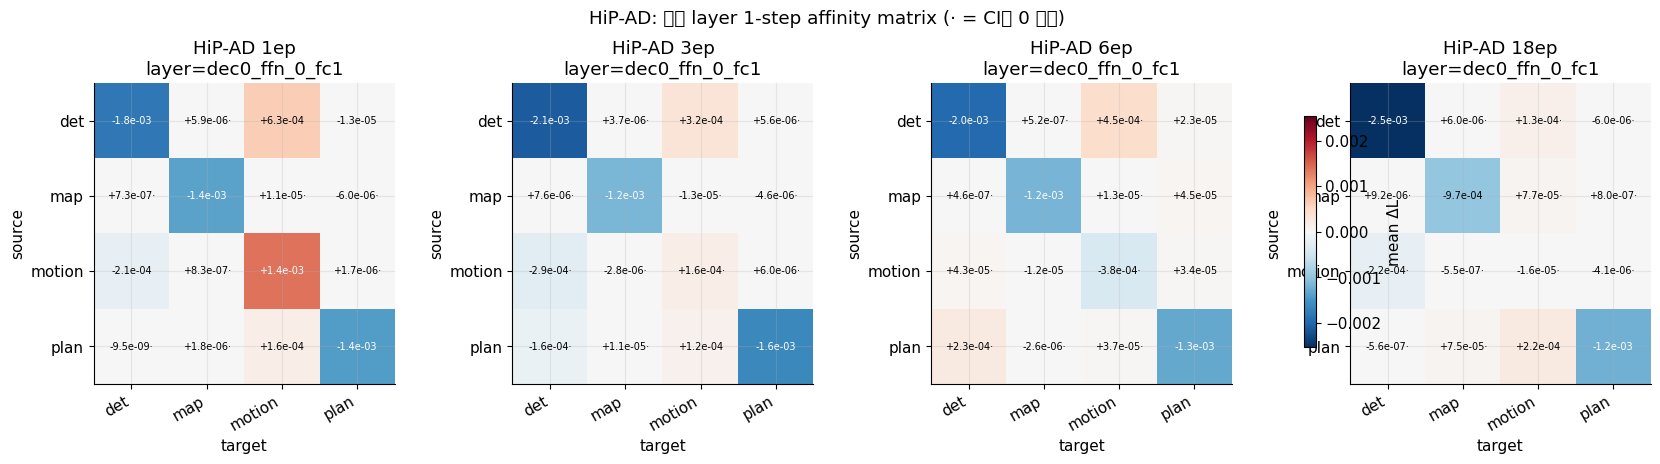

HiP-AD representative layer: dec0_ffn_0_fc1


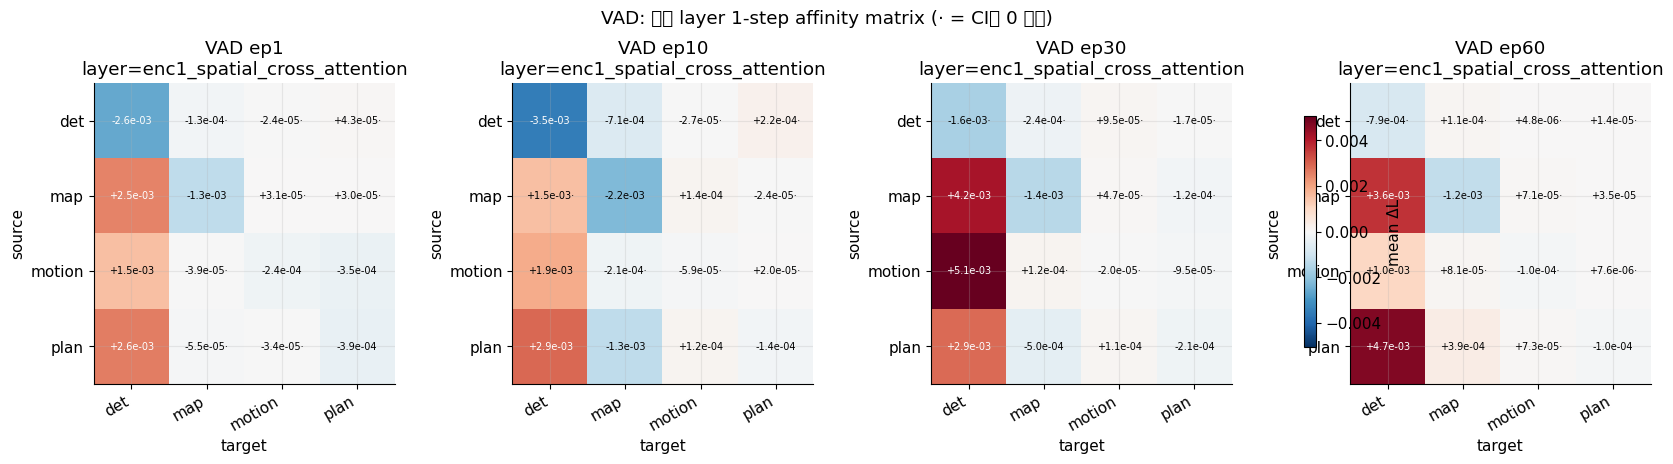

VAD representative layer: enc1_spatial_cross_attention


In [25]:
# ---- Extra helpers adapted from tools/gradient_analysis_viz.ipynb ----

def model_root(model: str) -> Path:
    return RUNS[model]


def model_ckpts(model: str):
    return [checkpoint_tag(p) for p in checkpoint_dirs(model_root(model))]


def probe_matrix_paths(model: str, ckpt: str, layer: str, variant: str = 'normalized', steps: int = 1):
    base = model_root(model) / f'ckpt_{ckpt}' / 'probe'
    prefix = f'probe_matrix_{layer}_{steps}step_{variant}'
    return base / f'{prefix}.csv', base / f'{prefix}_ci_lo.csv', base / f'{prefix}_ci_hi.csv'


def load_probe_matrix_ci(model: str, ckpt: str, layer: str, variant: str = 'normalized', steps: int = 1):
    mean_p, lo_p, hi_p = probe_matrix_paths(model, ckpt, layer, variant, steps)
    if not mean_p.exists():
        raise FileNotFoundError(mean_p)
    mean = pd.read_csv(mean_p, index_col=0).reindex(index=TASKS, columns=TASKS)
    lo = pd.read_csv(lo_p, index_col=0).reindex(index=TASKS, columns=TASKS) if lo_p.exists() else mean * np.nan
    hi = pd.read_csv(hi_p, index_col=0).reindex(index=TASKS, columns=TASKS) if hi_p.exists() else mean * np.nan
    return mean, lo, hi


def choose_representative_layer(model: str) -> str:
    # 원본 viz의 full-update matrix 대신, off-diagonal |ΔL|가 가장 큰 layer를 대표 layer로 고른다.
    sub = probe[(probe['model'] == model) & (probe['steps'].eq(1)) & (probe['variant'].eq('normalized'))]
    off = sub[sub['source_task'] != sub['target_task']].copy()
    ranked = (off.assign(abs_delta=lambda d: d['delta'].abs())
                .groupby('layer')['abs_delta'].mean()
                .sort_values(ascending=False))
    return ranked.index[0]


def plot_affinity_matrix_with_ci(model: str, layer=None, variant: str = 'normalized', steps: int = 1):
    if layer is None:
        layer = choose_representative_layer(model)
    ckpts = model_ckpts(model)
    mats = []
    for ck in ckpts:
        try:
            mean, _, _ = load_probe_matrix_ci(model, ck, layer, variant, steps)
            mats.append(mean.values)
        except FileNotFoundError:
            pass
    vmax = max([np.nanmax(np.abs(m)) for m in mats if np.isfinite(m).any()] or [1.0])
    vmax = max(vmax, 1e-6)

    fig, axes = plt.subplots(1, len(ckpts), figsize=(4.2 * len(ckpts), 4), squeeze=False)
    for ax, ck in zip(axes.flat, ckpts):
        try:
            mean, lo, hi = load_probe_matrix_ci(model, ck, layer, variant, steps)
        except FileNotFoundError:
            ax.axis('off')
            ax.set_title(f'{ck}\nmissing')
            continue
        M, L, H = mean.values, lo.values, hi.values
        im = ax.imshow(M, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='equal')
        ax.set_xticks(range(len(TASKS)))
        ax.set_xticklabels(TASKS, rotation=30, ha='right')
        ax.set_yticks(range(len(TASKS)))
        ax.set_yticklabels(TASKS)
        ax.set_title(f'{model} {ck}\nlayer={layer}')
        ax.set_xlabel('target')
        ax.set_ylabel('source')
        for i in range(len(TASKS)):
            for j in range(len(TASKS)):
                v = M[i, j]
                if not np.isfinite(v):
                    continue
                uncertain = np.isfinite(L[i, j]) and np.isfinite(H[i, j]) and (L[i, j] <= 0 <= H[i, j])
                text = f'{v:+.1e}' + ('·' if uncertain else '')
                color = 'white' if abs(v) > vmax * 0.45 else 'black'
                ax.text(j, i, text, ha='center', va='center', fontsize=7, color=color)
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75, label='mean ΔL')
    fig.suptitle(f'{model}: 대표 layer 1-step affinity matrix (· = CI가 0 포함)', y=1.05)
    plt.tight_layout()
    plt.show()
    return layer

for model in ['HiP-AD', 'VAD']:
    layer = plot_affinity_matrix_with_ci(model)
    print(f'{model} representative layer:', layer)

## E1. 대표 layer affinity matrix 해석

원본 Phase 1 노트북은 `_all` full-update affinity matrix를 그렸습니다. Phase 2는 layer-targeted probe로 실행되어 `_all` matrix가 없으므로, 여기서는 **off-diagonal 평균 |ΔL|가 가장 큰 layer**를 대표 layer로 골라 source→target matrix를 그립니다.

해석법은 다음입니다.

- 행은 source task입니다. 이 task의 gradient 방향으로 1-step virtual update를 합니다.
- 열은 target task입니다. update 이후 해당 target loss가 얼마나 변했는지 봅니다.
- 값이 음수면 target loss가 감소한 것입니다.
- 숫자 뒤의 `·` 표시는 bootstrap CI가 0을 포함한다는 뜻입니다. 즉 부호를 확신하기 어렵습니다.

이 그림은 helpful ratio보다 더 보수적입니다. helpful ratio가 0.55여도 평균 ΔL가 거의 0이고 CI가 0을 포함하면, 실제 효과는 약하다고 봐야 합니다.

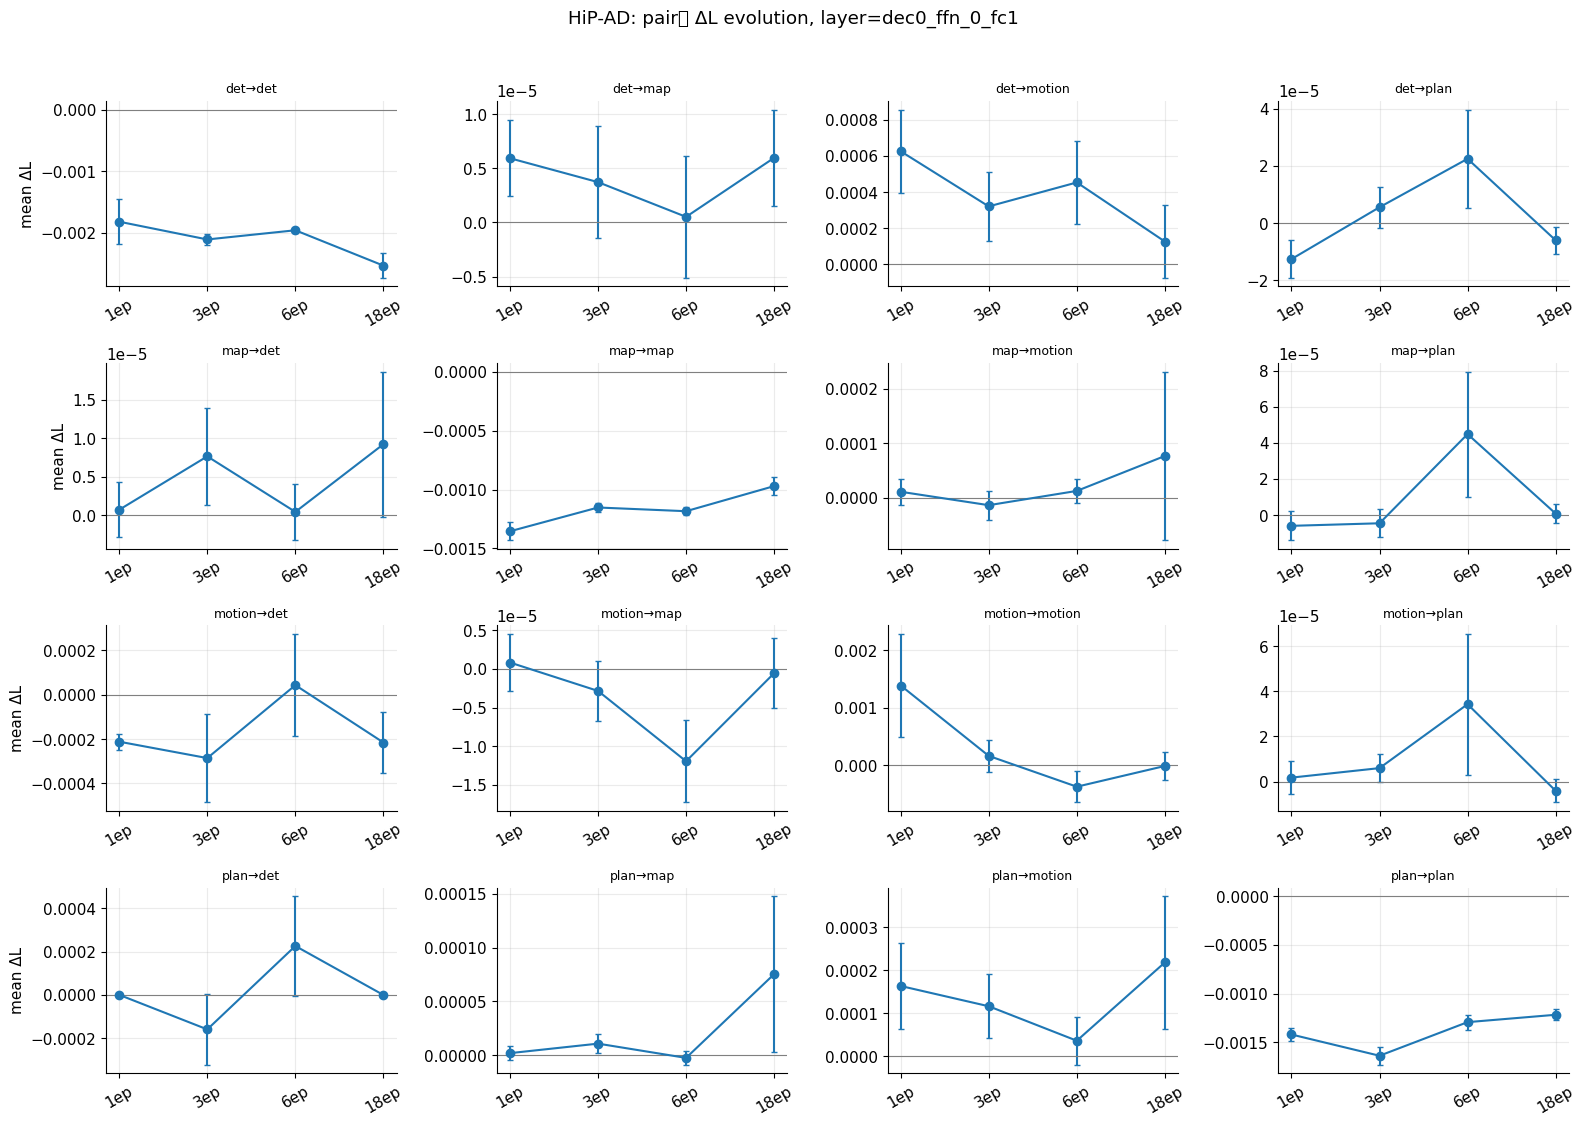

HiP-AD ΔL evolution layer: dec0_ffn_0_fc1


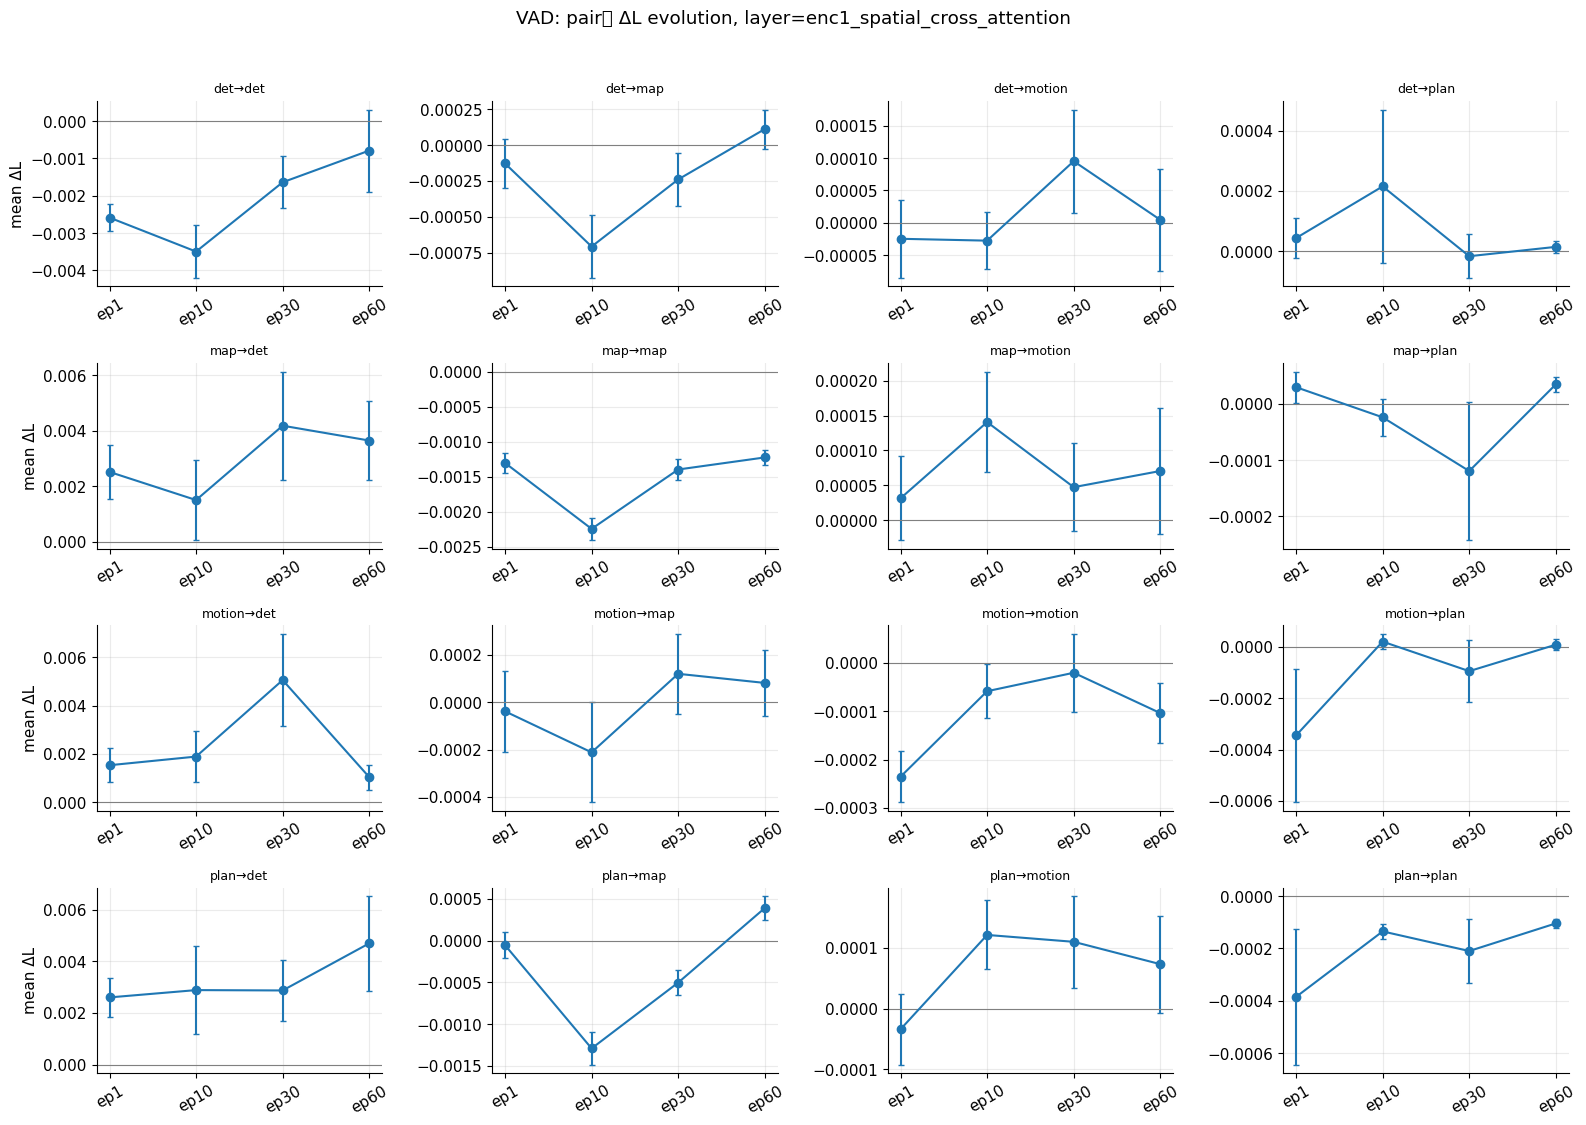

VAD ΔL evolution layer: enc1_spatial_cross_attention


In [26]:
def plot_pair_delta_evolution(model: str, layer=None, variant: str = 'normalized', steps: int = 1):
    if layer is None:
        layer = choose_representative_layer(model)
    sub = probe[(probe['model'] == model) & (probe['layer'] == layer)
                & (probe['variant'] == variant) & (probe['steps'] == steps)].copy()
    pairs = [(s, t) for s in TASKS for t in TASKS]
    fig, axes = plt.subplots(4, 4, figsize=(16, 11), sharex=False)
    for ax, (src, tgt) in zip(axes.flat, pairs):
        d = sub[(sub['source_task'] == src) & (sub['target_task'] == tgt)]
        if d.empty:
            ax.axis('off')
            continue
        agg = (d.groupby(['checkpoint', 'checkpoint_order'])['delta']
                 .agg(['mean', 'std', 'count'])
                 .reset_index()
                 .sort_values('checkpoint_order'))
        agg['sem'] = agg['std'] / np.sqrt(agg['count'])
        x = np.arange(len(agg))
        ax.errorbar(x, agg['mean'], yerr=agg['sem'], marker='o', capsize=2)
        ax.axhline(0, color='gray', linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(agg['checkpoint'], rotation=30)
        ax.set_title(f'{src}→{tgt}', fontsize=9)
        if ax in axes[:, 0]:
            ax.set_ylabel('mean ΔL')
    fig.suptitle(f'{model}: pair별 ΔL evolution, layer={layer}', y=1.02)
    plt.tight_layout()
    plt.show()
    return layer

for model in ['HiP-AD', 'VAD']:
    layer = plot_pair_delta_evolution(model)
    print(f'{model} ΔL evolution layer:', layer)

## E2. Pair별 ΔL evolution 해석

이 그림은 source→target 조합 16개를 모두 시간축으로 봅니다. 원본 노트북의 “task pair별 ΔL의 학습 진행 변화”를 Phase 2 layer probe에 맞춘 것입니다.

특히 봐야 하는 부분은 diagonal과 off-diagonal의 차이입니다.

- diagonal이 계속 음수이면 자기 task gradient가 자기 loss를 안정적으로 줄입니다.
- off-diagonal이 0 주변이면 cross-task 영향이 작습니다.
- off-diagonal이 반복적으로 양수이면 interference 후보입니다.
- off-diagonal이 반복적으로 음수이면 cooperation 후보입니다.

HiP-AD에서는 diagonal만 뚜렷하고 off-diagonal은 대부분 0 근처입니다. VAD는 일부 off-diagonal이 HiP-AD보다 더 방향성을 갖지만, 평균 ΔL 크기는 여전히 작습니다.

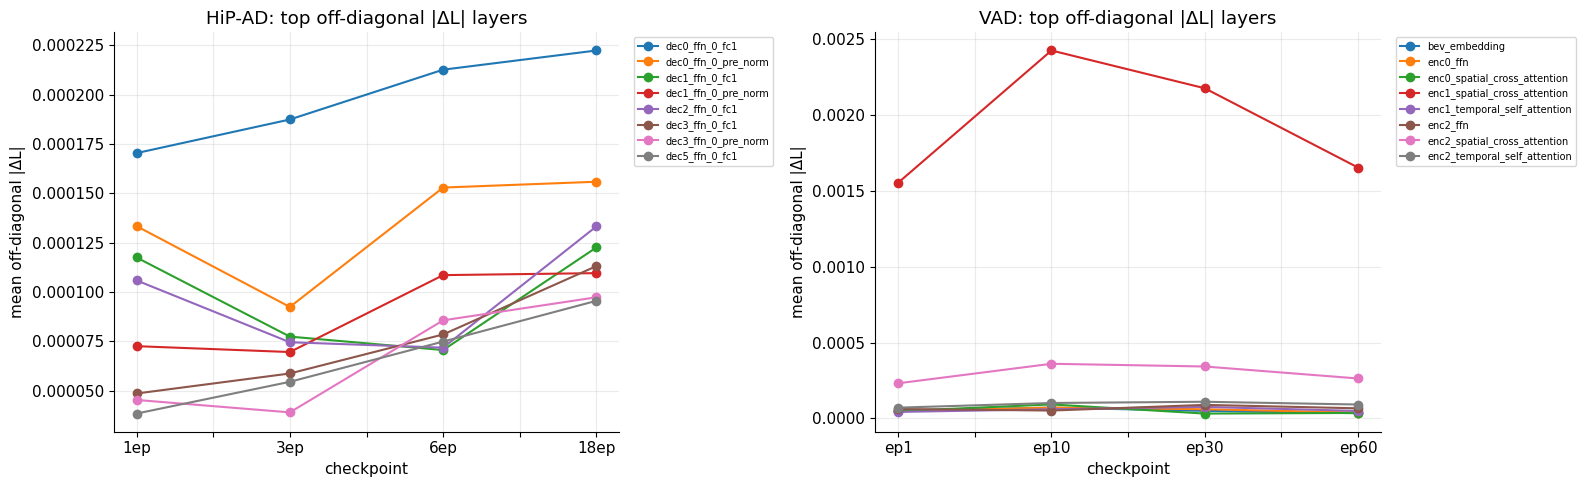

,model,layer,mean_abs_delta_offdiag
0,HiP-AD,dec0_ffn_0_fc1,0.000198
1,HiP-AD,dec0_ffn_0_pre_norm,0.000134
2,HiP-AD,dec1_ffn_0_fc1,0.000097
4,HiP-AD,dec2_ffn_0_fc1,0.000096
3,HiP-AD,dec1_ffn_0_pre_norm,0.000090
5,HiP-AD,dec3_ffn_0_fc1,0.000075
6,HiP-AD,dec3_ffn_0_pre_norm,0.000067
8,HiP-AD,dec5_ffn_0_fc1,0.000066
7,HiP-AD,dec4_ffn_0_fc1,0.000065
9,HiP-AD,dec5_ffn_0_pre_norm,0.000052


In [27]:
def offdiag_interference_table():
    sub = probe[(probe['steps'] == 1) & (probe['variant'] == 'normalized') & (probe['source_task'] != probe['target_task'])].copy()
    sub['abs_delta'] = sub['delta'].abs()
    return (sub.groupby(['model', 'checkpoint', 'checkpoint_order', 'layer'])['abs_delta']
              .mean()
              .reset_index(name='mean_abs_delta_offdiag')
              .sort_values(['model', 'checkpoint_order', 'mean_abs_delta_offdiag'], ascending=[True, True, False]))

ti = offdiag_interference_table()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
for ax, (model, df) in zip(axes, ti.groupby('model')):
    top_layers = (df.groupby('layer')['mean_abs_delta_offdiag'].mean()
                    .sort_values(ascending=False).head(8).index.tolist())
    pivot = (df[df['layer'].isin(top_layers)]
             .pivot_table(index='checkpoint', columns='layer', values='mean_abs_delta_offdiag')
             .reindex(sorted(df['checkpoint'].unique(), key=checkpoint_sort_key)))
    pivot.plot(marker='o', ax=ax)
    ax.set_title(f'{model}: top off-diagonal |ΔL| layers')
    ax.set_xlabel('checkpoint')
    ax.set_ylabel('mean off-diagonal |ΔL|')
    ax.legend(fontsize=7, ncol=1, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

display(ti.groupby(['model', 'layer'])['mean_abs_delta_offdiag'].mean().reset_index()
        .sort_values(['model', 'mean_abs_delta_offdiag'], ascending=[True, False])
        .groupby('model').head(10))

## E3. Off-diagonal interference layer 순위

원본 노트북의 `total_interference`는 off-diagonal 평균 |ΔL|가 큰 layer를 찾았습니다. 여기서도 같은 방식으로, source와 target이 다른 경우만 모아 layer별 평균 |ΔL|를 계산했습니다.

이 값이 큰 layer는 “task 간 virtual update가 서로의 loss에 영향을 많이 주는 layer”입니다. 단, 크다는 것이 곧 conflict라는 뜻은 아닙니다. 음수 방향이면 cooperation이고, 양수 방향이면 interference입니다. 그래서 이 결과는 conflict ratio와 함께 읽어야 합니다.

이 분석은 어떤 layer를 후속 정밀 분석 대상으로 삼을지 고르는 데 유용합니다.

In [28]:
def robust_batch_permutation_cells(min_pass_ckpts: int = 3):
    bp = null_baseline[null_baseline['null_kind'] == 'batch_permutation'].copy()
    agg = (bp.groupby(['model', 'task_a', 'task_b', 'group'])['passes_noise_threshold']
             .agg(pass_frac='mean', n_passing_ckpts='sum', n_ckpts='count')
             .reset_index())
    return agg[agg['n_passing_ckpts'] >= min_pass_ckpts].sort_values(['model', 'pass_frac'], ascending=[True, False])

robust_null = robust_batch_permutation_cells(min_pass_ckpts=3)
print(f'batch_permutation null을 3개 이상 checkpoint에서 통과한 cell 수: {len(robust_null)}')
display(robust_null)

if robust_null.empty:
    print('해석: batch_permutation 기준의 robust cell이 거의 없으면, global 구조적 conflict 주장은 약해진다.')

batch_permutation null을 3개 이상 checkpoint에서 통과한 cell 수: 12


,model,task_a,task_b,group,pass_frac,n_passing_ckpts,n_ckpts
3,HiP-AD,det,motion,fc_after,1.00,4,4
5,HiP-AD,det,motion,neck,1.00,4,4
4,HiP-AD,det,motion,fc_before,0.75,3,4
28,VAD,det,motion,bev_embedding,1.00,4,4
29,VAD,det,motion,enc0_ffn,1.00,4,4
30,VAD,det,motion,enc0_spatial_cross_attention,1.00,4,4
31,VAD,det,motion,enc0_temporal_self_attention,1.00,4,4
32,VAD,det,motion,enc1_ffn,1.00,4,4
34,VAD,det,motion,enc1_temporal_self_attention,1.00,4,4
35,VAD,det,motion,enc2_ffn,1.00,4,4


## E4. Robust null cell 해석

`sign_flip`은 평균이 0에서 벗어났는지를 잘 잡지만, batch 구조를 보존한 강한 신호인지까지 보려면 `batch_permutation`이 더 보수적입니다.

따라서 여러 checkpoint에서 `batch_permutation` null을 반복 통과하는 cell은 더 믿을 만한 후보입니다.

- robust cell이 적으면: conflict처럼 보이는 cell이 있어도 global하고 안정적인 구조라고 말하기 어렵습니다.
- robust cell이 많으면: 특정 task pair/layer의 interaction이 학습 전반에 걸쳐 반복된다는 뜻입니다.

이 표는 보고서에서 “정말 신뢰할 만한 conflict/cooperation 후보”를 골라낼 때 쓰면 좋습니다.

,model,checkpoint,checkpoint_order,heavy_tail_cells,new_heavy_tail_cells
0,HiP-AD,1ep,1,0,0
1,HiP-AD,3ep,3,0,0
2,HiP-AD,6ep,6,0,0
3,HiP-AD,18ep,18,0,0
4,VAD,ep1,1,4,4
5,VAD,ep10,10,9,6
6,VAD,ep30,30,6,3
7,VAD,ep60,60,3,1


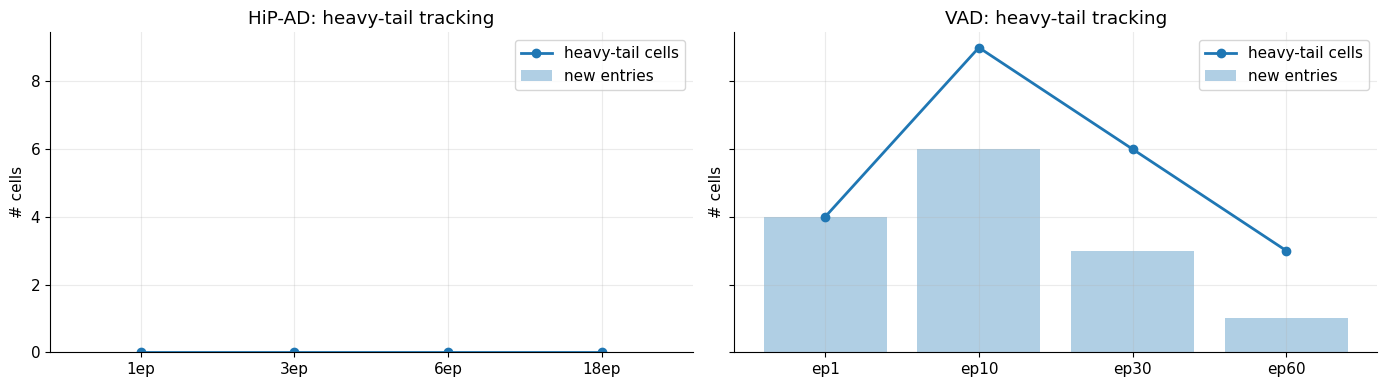


HiP-AD: heavy-tail cell 없음

VAD: top heavy-tail cells by kurtosis


,checkpoint,task_a,task_b,group,kurtosis,p1,p50,p99
283,ep60,map,motion,enc0_temporal_self_attention,17.822062,-0.376964,0.000023,0.201501
133,ep10,det,map,enc0_temporal_self_attention,16.546407,-0.275171,-0.003948,0.116966
223,ep30,map,motion,enc0_temporal_self_attention,15.154677,-0.197300,-0.002988,0.123821
233,ep30,map,plan,enc0_temporal_self_attention,14.807067,-0.205682,0.001817,0.515404
293,ep60,map,plan,enc0_temporal_self_attention,12.858069,-0.584262,-0.001314,0.532213
183,ep10,motion,plan,enc0_temporal_self_attention,12.638833,-0.476272,0.012449,0.806673
253,ep60,det,map,enc0_temporal_self_attention,11.861002,-0.182537,0.000199,0.125613
242,ep30,motion,plan,bev_embedding,10.528586,-0.318014,0.028275,0.192336
132,ep10,det,map,bev_embedding,10.506190,-0.033026,0.002014,0.016513
153,ep10,det,plan,enc0_temporal_self_attention,10.353170,-0.367100,-0.004416,0.355578


In [29]:
def heavy_tail_tracking():
    rows = []
    for model, df in distribution.groupby('model'):
        prev = set()
        for ck in sorted(df['checkpoint'].unique(), key=checkpoint_sort_key):
            sub = df[(df['checkpoint'] == ck) & (df['shape_label'] == 'heavy-tail')]
            cur = set(zip(sub['task_a'], sub['task_b'], sub['group']))
            rows.append({
                'model': model,
                'checkpoint': ck,
                'checkpoint_order': checkpoint_sort_key(ck),
                'heavy_tail_cells': len(cur),
                'new_heavy_tail_cells': len(cur - prev),
            })
            prev = cur
    return pd.DataFrame(rows).sort_values(['model', 'checkpoint_order'])

ht_track = heavy_tail_tracking()
display(ht_track)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, (model, df) in zip(axes, ht_track.groupby('model')):
    d = df.sort_values('checkpoint_order')
    ax.plot(d['checkpoint'], d['heavy_tail_cells'], marker='o', linewidth=2, label='heavy-tail cells')
    ax.bar(d['checkpoint'], d['new_heavy_tail_cells'], alpha=0.35, label='new entries')
    ax.set_title(f'{model}: heavy-tail tracking')
    ax.set_ylabel('# cells')
    ax.legend()
plt.tight_layout()
plt.show()

for model in ['HiP-AD', 'VAD']:
    df = distribution[(distribution['model'] == model) & (distribution['shape_label'] == 'heavy-tail')].copy()
    if df.empty:
        print(f'\n{model}: heavy-tail cell 없음')
        continue
    print(f'\n{model}: top heavy-tail cells by kurtosis')
    display(df.sort_values('kurtosis', ascending=False)
              [['checkpoint', 'task_a', 'task_b', 'group', 'kurtosis', 'p1', 'p50', 'p99']]
              .head(12))

## E5. Heavy-tail 추적 해석

Heavy-tail cell은 평균 cosine이나 평균 ΔL가 outlier batch에 휘둘릴 수 있는 곳입니다. 이런 cell에서는 mean만 보고 결론을 내리면 위험합니다.

- HiP-AD에서 heavy-tail이 적거나 없다면, 평균 기반 해석의 위험이 상대적으로 작습니다.
- VAD에서 heavy-tail이 특정 layer/task pair에 몰리면, 그 pair는 batch별 사례 분석이 필요합니다.

특히 VAD의 BEV encoder layer에서 heavy-tail과 high conflict가 겹치면, “일부 장면/배치에서 매우 강한 task tension이 생긴다”는 후속 분석 질문으로 이어질 수 있습니다.

base-conflict CI lower bound >= 0.5 cells: 6


,model,checkpoint,task_a,task_b,group,conflict_ratio,conflict_ratio_ci_lo,conflict_ratio_ci_hi,mean_cos
44,HiP-AD,6ep,det,plan,neck,0.62,0.52,0.71,-0.009740
25,HiP-AD,3ep,det,plan,fc_before,0.60,0.50,0.69,-0.025566
297,VAD,ep60,map,plan,enc1_spatial_cross_attention,0.65,0.55,0.74,-0.173075
293,VAD,ep60,map,plan,enc0_ffn,0.64,0.54,0.73,-0.071503
95,VAD,ep1,det,plan,enc0_temporal_self_attention,0.61,0.51,0.70,-0.018339
103,VAD,ep1,map,motion,enc0_ffn,0.60,0.50,0.69,-0.031680


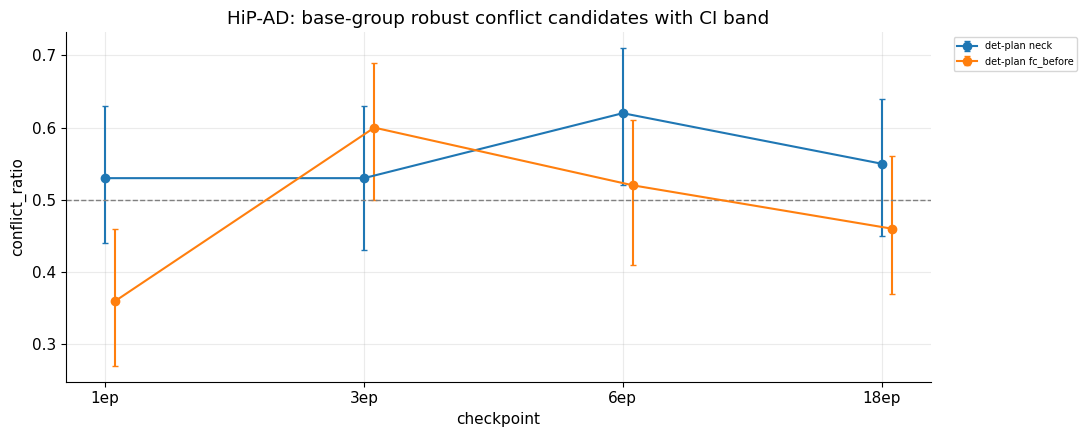

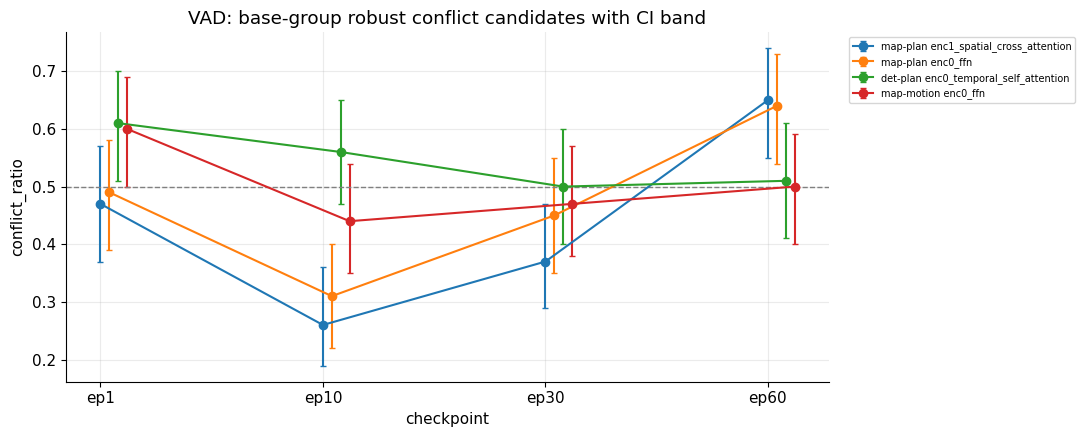

In [30]:
def conflict_ci_candidates(min_ci_lo: float = 0.5):
    # Bootstrap CI columns are present in the base conflict summaries, not in layer_conflict.
    # This follows the original gradient_analysis_viz.ipynb CI-band analysis.
    df = real_base_conflict.copy()
    required = {'conflict_ratio_ci_lo', 'conflict_ratio_ci_hi'}
    if not required.issubset(df.columns):
        print('conflict CI columns missing in base_conflict')
        return pd.DataFrame()
    cand = df[df['conflict_ratio_ci_lo'] >= min_ci_lo].copy()
    return cand.sort_values(['model', 'conflict_ratio_ci_lo', 'conflict_ratio'], ascending=[True, False, False])

ci_cand = conflict_ci_candidates(0.5)
print(f'base-conflict CI lower bound >= 0.5 cells: {len(ci_cand)}')
cols = ['model', 'checkpoint', 'task_a', 'task_b', 'group', 'conflict_ratio', 'conflict_ratio_ci_lo', 'conflict_ratio_ci_hi', 'mean_cos']
if not ci_cand.empty:
    display(ci_cand[cols].head(40))
else:
    print('CI lower bound가 0.5 이상인 base conflict 후보가 없습니다.')

for model, df in ci_cand.groupby('model'):
    keys = df[['task_a', 'task_b', 'group']].drop_duplicates().head(8)
    if keys.empty:
        print(f'{model}: CI_lo >= 0.5 후보 없음')
        continue
    fig, ax = plt.subplots(figsize=(11, 4.5))
    model_df = real_base_conflict[real_base_conflict['model'] == model]
    ckpts = sorted(model_df['checkpoint'].unique(), key=checkpoint_sort_key)
    for k, row in enumerate(keys.itertuples(index=False)):
        a, b, g = row.task_a, row.task_b, row.group
        sub = model_df[(model_df['task_a'] == a) & (model_df['task_b'] == b) & (model_df['group'] == g)].sort_values('checkpoint_order')
        if sub.empty:
            continue
        x = np.arange(len(sub)) + 0.04 * k
        cr = sub['conflict_ratio'].to_numpy()
        lo = sub['conflict_ratio_ci_lo'].to_numpy()
        hi = sub['conflict_ratio_ci_hi'].to_numpy()
        ax.errorbar(x, cr, yerr=[cr - lo, hi - cr], marker='o', capsize=2, label=f'{a}-{b} {g}')
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_xticks(range(len(ckpts)))
    ax.set_xticklabels(ckpts)
    ax.set_title(f'{model}: base-group robust conflict candidates with CI band')
    ax.set_ylabel('conflict_ratio')
    ax.set_xlabel('checkpoint')
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## E6. Conflict CI band 해석

Conflict ratio가 0.6이어도 bootstrap CI가 넓으면 안정적인 후보가 아닐 수 있습니다. 그래서 `conflict_ratio_ci_lo >= 0.5`인 cell을 따로 봅니다.

이 기준을 통과하는 cell은 “bootstrap으로 봐도 conflict ratio가 절반 이상일 가능성이 높은 후보”입니다.

- HiP-AD에서 이 후보가 적고 mean cosine이 작다면, direction conflict는 여전히 약한 보조 신호입니다.
- VAD에서 이 후보가 `map-plan` / BEV encoder layer에 몰리면, VAD의 local conflict 주장을 뒷받침합니다.

,model,checkpoint,checkpoint_order,source_task,variant,self_violation_rate
8,HiP-AD,1ep,1,det,normalized,0.012
9,HiP-AD,1ep,1,det,raw,0.115
10,HiP-AD,1ep,1,map,normalized,0.035
11,HiP-AD,1ep,1,map,raw,0.208
12,HiP-AD,1ep,1,motion,normalized,0.357
...,...,...,...,...,...,...
59,VAD,ep60,60,map,raw,0.314
60,VAD,ep60,60,motion,normalized,0.232
61,VAD,ep60,60,motion,raw,0.317
62,VAD,ep60,60,plan,normalized,0.228


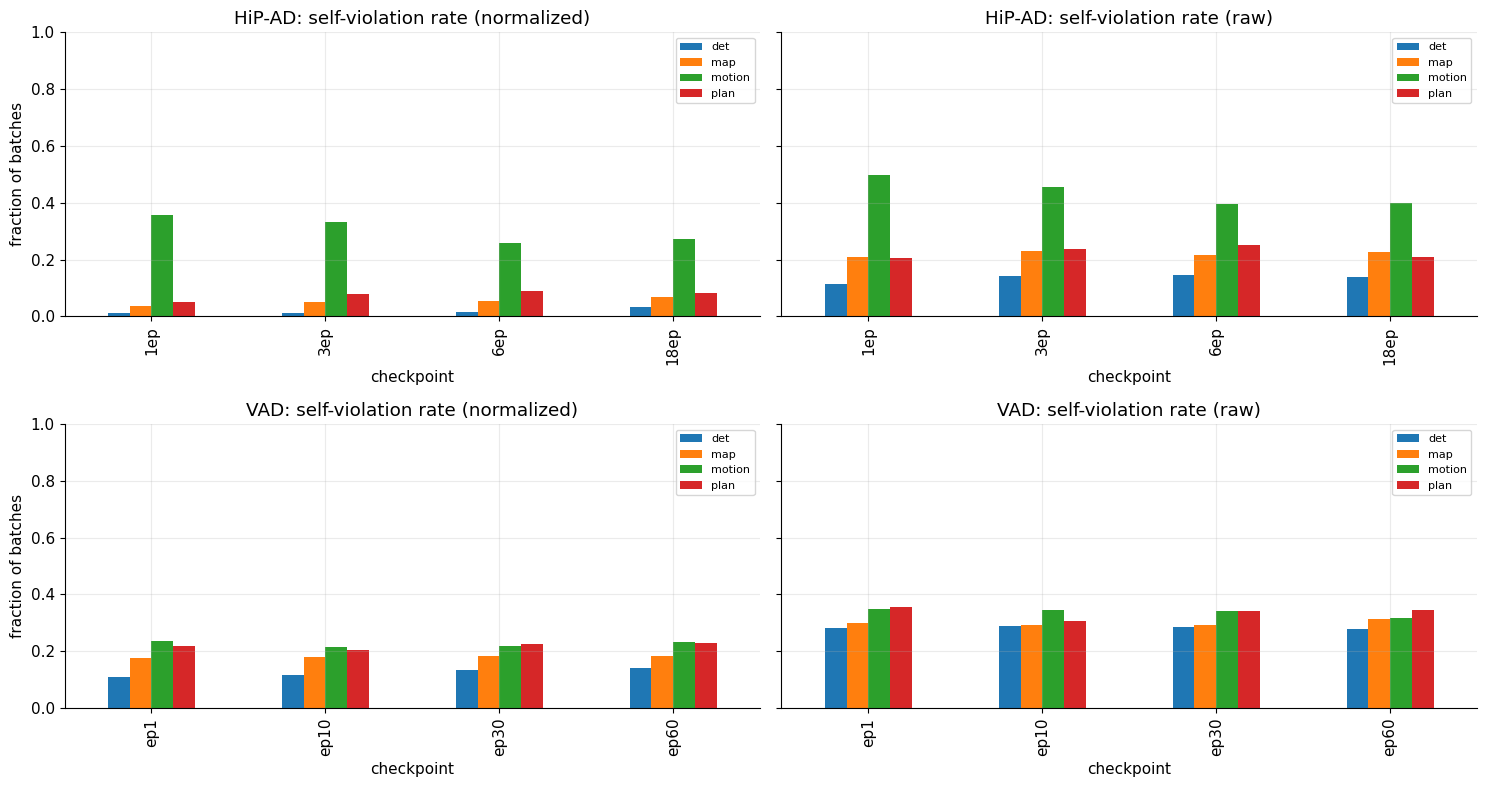

In [31]:
def self_violation_table():
    diag = probe[(probe['source_task'] == probe['target_task']) & (probe['steps'] == 1)].copy()
    diag['violates'] = diag['delta'] > 0
    return (diag.groupby(['model', 'checkpoint', 'checkpoint_order', 'source_task', 'variant'])['violates']
              .mean()
              .reset_index(name='self_violation_rate')
              .sort_values(['model', 'checkpoint_order', 'source_task', 'variant']))

viol = self_violation_table()
display(viol)

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharey=True)
for row, model in enumerate(['HiP-AD', 'VAD']):
    for col, variant in enumerate(['normalized', 'raw']):
        ax = axes[row, col]
        sub = viol[(viol['model'] == model) & (viol['variant'] == variant)]
        pivot = sub.pivot_table(index='checkpoint', columns='source_task', values='self_violation_rate')
        pivot = pivot.reindex(sorted(pivot.index, key=checkpoint_sort_key))[TASKS]
        pivot.plot(kind='bar', ax=ax)
        ax.set_title(f'{model}: self-violation rate ({variant})')
        ax.set_ylabel('fraction of batches')
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## E7. Self-violation 해석

Self-violation은 source task와 target task가 같은데도, 그 task gradient 방향으로 1-step 이동한 뒤 자기 loss가 증가한 비율입니다.

정상적인 smooth loss landscape라면 diagonal step은 대부분 자기 loss를 줄여야 합니다. self-violation이 높으면 다음 가능성을 의심해야 합니다.

1. loss landscape가 매우 비선형이거나 flat하다.
2. step size가 해당 task/layer에 비해 크다.
3. matching, temporal state, augmentation 같은 stochastic source가 완전히 고정되지 않았다.
4. 해당 task의 gradient signal이 작아 numerical noise의 영향을 크게 받는다.

HiP-AD Phase 1에서 motion source가 probe-unfriendly하다는 결론이 있었고, 이 표는 Phase 2에서도 그런 종류의 불안정성을 task별로 확인하는 용도입니다.

# 최종 결론과 보고 문장

## 최종 결론

1. **HiP-AD**는 Phase 1의 Pass B 결론을 유지합니다. Direction conflict는 일부 layer에서 보이지만 global signal은 약하고, 1-step probe도 cross-task transfer가 강하지 않습니다.
2. **VAD**는 HiP-AD보다 direction-conflict signal이 더 분명합니다. 특히 `map-plan`과 `enc0/enc1` BEV encoder 계열 layer가 중요합니다.
3. 하지만 **두 모델 모두 magnitude imbalance가 큰 병목**입니다. VAD는 det gradient가 매우 크고 motion/plan gradient가 작아 imbalance가 더 심합니다.
4. 1-step probe task별 분석은 “diagonal은 강하지만 off-diagonal은 제한적”이라는 공통 패턴을 보입니다. VAD의 off-diagonal helpful이 약간 더 높지만 delta 크기가 작아 강한 transfer로 보기는 어렵습니다.

## 논문/보고서용 한국어 문장

> Phase 2 분석 결과, HiP-AD와 VAD 모두 전역적인 gradient direction conflict보다는 task-wise gradient magnitude imbalance가 더 지배적인 병목으로 나타났다. HiP-AD에서는 layer-level conflict ratio가 0.5 근처인 cell이 존재하지만 mean cosine과 null-baseline signal이 약해 global direction-conflict story는 유지되기 어렵다. 반면 VAD는 `map-plan` 중심의 BEV encoder layer에서 더 선명한 local direction-conflict가 관측된다. 그러나 VAD 역시 det gradient norm이 motion/plan보다 훨씬 커서 magnitude imbalance가 주된 최적화 문제로 남는다. 따라서 Phase 3의 주요 algorithmic desiderata는 magnitude rescaling과 temporal scheduling이며, VAD류 구조에 대해서만 layer-local direction handling을 보조 메커니즘으로 다루는 것이 타당하다.

## 영어 보고 문장

> Phase 2 shows that both HiP-AD and VAD are dominated by task-wise gradient magnitude imbalance rather than globally strong pairwise direction conflict. HiP-AD exhibits weak near-zero directional signals after null testing, whereas VAD additionally shows localized map-plan conflict in early/mid BEV encoder layers. This supports magnitude rescaling and temporal scheduling as primary algorithmic desiderata, with layer-local direction handling as a secondary mechanism for VAD-like architectures.